In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)
pd.options.display.float_format = '{:,.0f}'.format

In [ ]:
credits=pd.read_csv('/content/tmdb_5000_credits.csv', engine='python')
movies=pd.read_csv("/content/tmdb_5000_movies.csv", engine='python')

In [ ]:
credits.head(1)

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [ ]:
movies.head(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7,11800


In [ ]:
df = movies.merge(credits, on="title")
df.head(2)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,7,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."


In [ ]:
df.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count', 'movie_id', 'cast', 'crew'], dtype='object')

## Future Selected


In [ ]:
df=df[["budget", "popularity", "vote_average", "vote_count","genres","cast","crew","revenue","production_companies","release_date", "title"]]
df.head(1)

,budget,popularity,vote_average,vote_count,genres,cast,crew,revenue,production_companies,release_date,title
0,237000000,150,7,11800,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",2787965087,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,Avatar


In [ ]:
df.shape

(4809, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4809 non-null   int64  
 1   popularity            4809 non-null   float64
 2   vote_average          4809 non-null   float64
 3   vote_count            4809 non-null   int64  
 4   genres                4809 non-null   object 
 5   cast                  4809 non-null   object 
 6   crew                  4809 non-null   object 
 7   revenue               4809 non-null   int64  
 8   production_companies  4809 non-null   object 
 9   release_date          4808 non-null   object 
 10  title                 4809 non-null   object 
dtypes: float64(2), int64(3), object(6)
memory usage: 413.4+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
budget,"4,809","29,027,803","40,704,731",0,"780,000","15,000,000","40,000,000","380,000,000"
popularity,"4,809",21,32,0,5,13,28,876
vote_average,"4,809",6,1,0,6,6,7,10
vote_count,"4,809",690,"1,234",0,54,235,737,"13,752"
revenue,"4,809","82,275,112","162,837,854",0,0,"19,170,001","92,913,171","2,787,965,087"


In [ ]:
df.isnull().sum()

,0
budget,0
popularity,0
vote_average,0
vote_count,0
genres,0
cast,0
crew,0
revenue,0
production_companies,0
release_date,1


In [ ]:
df=df.dropna()
df.isnull().sum()

,0
budget,0
popularity,0
vote_average,0
vote_count,0
genres,0
cast,0
crew,0
revenue,0
production_companies,0
release_date,0


In [ ]:
df = df[df["budget"] > 0]
df=df[df["revenue"] > 0]
df.shape

(3232, 11)

## JSON formatını düzeltme

In [ ]:
import ast

def convert(obj):
    L = []
    if isinstance(obj, str): # Add a check to ensure obj is a string before literal_eval
        try:
            for i in ast.literal_eval(obj):
                if 'name' in i: # Ensure 'name' key exists
                    L.append(i['name'])
        except (ValueError, SyntaxError):
            # Handle cases where literal_eval fails, e.g., if obj is not a valid literal
            pass
    return L

def fetch_director(obj):
    L = []
    if isinstance(obj, str): # Add a check to ensure obj is a string before literal_eval
        try:
            for i in ast.literal_eval(obj):
                if i.get('job') == 'Director' and 'name' in i:
                    L.append(i['name'])
                    break # Assuming only one director per movie
        except (ValueError, SyntaxError):
            # Handle cases where literal_eval fails
            pass
    return L

df['genres'] = df['genres'].apply(convert)
df['cast'] = df['cast'].apply(convert)
df['crew'] = df['crew'].apply(fetch_director) # Apply fetch_director directly to the original 'crew'
df['production_companies'] = df['production_companies'].apply(convert)

In [ ]:
df.head(1)

,budget,popularity,vote_average,vote_count,genres,cast,crew,revenue,production_companies,release_date,title
0,237000000,150,7,11800,"[Action, Adventure, Fantasy, Science Fiction]","[Sam Worthington, Zoe Saldana, Sigourney Weave...",[James Cameron],2787965087,"[Ingenious Film Partners, Twentieth Century Fo...",2009-12-10,Avatar


## Enflasyon

Enflasyon, paranın zaman içindeki satın alma gücündeki değişimi ifade eder. Filmlerin bütçe ve gelir rakamları genellikle çekildiği veya yayınlandığı yılın dolar değeriyle ifade edilir. Ancak, farklı yıllara ait finansal verileri karşılaştırmak için bu rakamların **bugünün dolar değeri** cinsinden ifade edilmesi gerekir. Bunu yapmak için, Tüketici Fiyat Endeksi (CPI) verilerini kullanacağız. CPI, belirli bir dönemdeki mal ve hizmet sepetinin fiyat değişimini ölçer. CPI verilerini kullanarak, eski yıllardaki bütçe ve gelirleri güncel dolar değerine çevirerek daha doğru bir karşılaştırma yapabiliriz.

Burada, basitleştirilmiş bir CPI veri setini (`cpi_data.csv` olarak varsayalım) dışarıdan yüklüyoruz. Eğer gerçek bir proje olsaydı, bu verileri güvenilir bir kaynaktan (örneğin; Dünya Bankası, FRED) çekmek gerekecekti.
her yıl %3 üstel artışla yeniden hesapland

In [ ]:


# Örnek bir CPI veri seti oluşturma (Gerçek projede dış kaynaktan yüklenecektir)
start_year = 1916
end_year = 2016 # current_year'dan 1 önceki yıl, çünkü current_year = cpi_df['year'].max() olacak

cpi_years = range(start_year, end_year + 1)

# İlk yılın CPI değeri
base_cpi = 10.0
annual_growth_rate = 0.03 # %3 artış

cpi_values = []
for i, year in enumerate(cpi_years):
    if i == 0:
        cpi_values.append(base_cpi)
    else:
        cpi_values.append(cpi_values[-1] * (1 + annual_growth_rate))

cpi_data = {
    'year': list(cpi_years),
    'cpi': cpi_values
}
cpi_df = pd.DataFrame(cpi_data)

# Oranlama için 'current_year'ı en güncel yıl olarak alalım
current_year = cpi_df['year'].max() # 2016
current_cpi = cpi_df[cpi_df['year'] == current_year]['cpi'].iloc[0]

# CPI df'ini göster
display(cpi_df.head())
display(f"Current year for CPI reference: {current_year}, CPI: {current_cpi}")

,year,cpi
0,1916,10
1,1917,10
2,1918,11
3,1919,11
4,1920,11


'Current year for CPI reference: 2016, CPI: 192.1863198085629'

In [ ]:
# CPI verilerini df ile birleştirme
df["year"] = pd.to_datetime(df["release_date"]).dt.year
df = pd.merge(df, cpi_df, on='year', how='left')

# Enflasyon düzeltmesi yapma
# Düzeltilmiş Bütçe = Orijinal Bütçe * (Güncel Yıl CPI / Filmin Yayın Yılı CPI)
df['budget_adjusted'] = df['budget'] * (current_cpi / df['cpi'])
df['revenue_adjusted'] = df['revenue'] * (current_cpi / df['cpi'])

# Yeni sütunları incele
display(df[['year', 'budget', 'revenue', 'cpi', 'budget_adjusted', 'revenue_adjusted']].head())

,year,budget,revenue,cpi,budget_adjusted,revenue_adjusted
0,2009,237000000,2787965087,156,"291,480,106","3,428,845,398"
1,2007,300000000,961000000,147,"391,431,955","1,253,887,030"
2,2015,245000000,880674609,187,"252,350,000","907,094,847"
3,2012,250000000,1084939099,171,"281,377,202","1,221,108,514"
4,2012,260000000,284139100,171,"292,632,291","319,801,060"


Artık `budget_adjusted` ve `revenue_adjusted` sütunları, filmlerin finansal performansını enflasyondan arındırılmış bir şekilde daha doğru bir şekilde karşılaştırmamızı sağlıyor. Bu yeni değerler üzerinden tekrar analizler yaparak daha sağlam çıkarımlar elde edebiliriz.

## Profit, Hit ve ROI oluşturma

In [ ]:
df["profit"] = df["revenue_adjusted"] - df["budget_adjusted"]# kar sütunu oluşturdum
df["roi"] = df["revenue_adjusted"] / (df["budget_adjusted"] )# tahsilata göre kaç katı kar ettiğine baktım

df["hit"] = (
    (df["revenue_adjusted"] > df["revenue_adjusted"].quantile(0.75)) #En çok kazanan %25’lik dilimdeki filmleri “hit” olarak etiketledm
).astype(int)

In [ ]:
df.head(1)

,budget,popularity,vote_average,vote_count,genres,cast,crew,revenue,production_companies,release_date,title,year,cpi,budget_adjusted,revenue_adjusted,profit,roi,hit
0,237000000,150,7,11800,"[Action, Adventure, Fantasy, Science Fiction]","[Sam Worthington, Zoe Saldana, Sigourney Weave...",[James Cameron],2787965087,"[Ingenious Film Partners, Twentieth Century Fo...",2009-12-10,Avatar,2009,156,"291,480,106","3,428,845,398","3,137,365,292",12,1


In [ ]:
df["hit"].value_counts()

,count
hit,
0,2424
1,808


## Weighted Score


In [ ]:
C = df['vote_average'].mean()
m = df['vote_count'].quantile(0.90)

print(f"Tüm filmlerin ortalama puanı (C): {C:.2f}")
print(f"Listelenmek için gereken minimum oy sayısı (m - 90. persentil): {m:.0f}")

Tüm filmlerin ortalama puanı (C): 6.31
Listelenmek için gereken minimum oy sayısı (m - 90. persentil): 2487


In [ ]:
def weighted_rating(x, m, C):
    v = x['vote_count']
    R = x['vote_average']
    return (v / (v + m)) * R + (m / (v + m)) * C

df['weighted_score'] = df.apply(lambda x: weighted_rating(x, m, C), axis=1)

df_sorted = df.sort_values('weighted_score', ascending=False)
display(df_sorted[['title', 'vote_count', 'vote_average', 'weighted_score']].head(10))

,title,vote_count,vote_average,weighted_score
1672,The Shawshank Redemption,8205,8,8
636,Fight Club,9413,8,8
65,The Dark Knight,12002,8,8
2576,Pulp Fiction,8428,8,8
95,Inception,13752,8,8
2633,The Godfather,5893,8,8
94,Interstellar,10867,8,8
766,Forrest Gump,7927,8,8
324,The Lord of the Rings: The Return of the King,8064,8,8
1753,The Empire Strikes Back,5879,8,8


## Cast Score

In [ ]:
# 1. df_cast DataFrame'ini kullanarak her oyuncunun ortalama enflasyon düzeltmeli gelirini hesaplayın
# df_cast, her bir oyuncunun ayrı satırlarda olduğu patlatılmış bir DataFrame'dir.
df_cast = df.explode("cast") # df_cast'i revenue_adjusted eklendikten sonra yeniden oluştur
actor_avg_revenue_adjusted = df_cast.groupby('cast')['revenue_adjusted'].mean()

# Ortalama gelir haritasını bir sözlüğe dönüştürün
actor_avg_revenue_map = actor_avg_revenue_adjusted.to_dict()

# 2. Her film için cast_score oluşturun
def calculate_cast_score(cast_list, actor_map, default_value=0):
    if not isinstance(cast_list, list) or not cast_list:
        return default_value

    actor_revenues = [actor_map.get(actor, default_value) for actor in cast_list]

    # Eğer listede geçerli gelir değeri yoksa (tüm oyuncular haritada bulunamazsa) 0 döndür
    if not actor_revenues:
        return default_value

    return sum(actor_revenues) / len(actor_revenues)

# df'e 'cast_score' sütununu ekleyin
df['cast_score'] = df['cast'].apply(lambda x: calculate_cast_score(x, actor_avg_revenue_map, df['revenue_adjusted'].mean()))

# Yeni sütunu kontrol edin
display(df[['title', 'cast', 'cast_score', 'revenue_adjusted']].head())

,title,cast,cast_score,revenue_adjusted
0,Avatar,"[Sam Worthington, Zoe Saldana, Sigourney Weave...","2,512,560,125","3,428,845,398"
1,Pirates of the Caribbean: At World's End,"[Johnny Depp, Orlando Bloom, Keira Knightley, ...","693,831,475","1,253,887,030"
2,Spectre,"[Daniel Craig, Christoph Waltz, Léa Seydoux, R...","771,528,357","907,094,847"
3,The Dark Knight Rises,"[Christian Bale, Michael Caine, Gary Oldman, A...","807,644,245","1,221,108,514"
4,John Carter,"[Taylor Kitsch, Lynn Collins, Samantha Morton,...","274,950,993","319,801,060"


In [ ]:
df.head(1)

,budget,popularity,vote_average,vote_count,genres,cast,crew,revenue,production_companies,release_date,title,year,cpi,budget_adjusted,revenue_adjusted,profit,roi,hit,weighted_score,cast_score
0,237000000,150,7,11800,"[Action, Adventure, Fantasy, Science Fiction]","[Sam Worthington, Zoe Saldana, Sigourney Weave...",[James Cameron],2787965087,"[Ingenious Film Partners, Twentieth Century Fo...",2009-12-10,Avatar,2009,156,"291,480,106","3,428,845,398","3,137,365,292",12,1,7,"2,512,560,125"


## Director Score

In [ ]:
df['director'] = df['crew'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)
# 1. Her yönetmenin ortalama (enflasyon düzeltilmiş) hasılatını hesapla
director_means = df.groupby('director')['revenue_adjusted'].mean()

# 2. Her yönetmenin kaç film çektiğini say
director_counts = df.groupby('director')['revenue_adjusted'].count()

# 3. Güvenilir bir skor için: Sadece en az 2 veya 3 film çekmiş olanları dikkate alalım
# (Tek filmle tesadüfi başarı yakalayanları elemek için)
qualified_directors = director_counts[director_counts >= 2].index

# 4. Skorları oluştur:
# Listede olanlara ortalama hasılatını, olmayanlara (yeni/az filmi olanlara)
# tüm veri setinin ortalama hasılatını veriyoruz.
overall_mean_revenue = df['revenue_adjusted'].mean()

def calculate_director_score(row):
    director = row['director']
    if director in qualified_directors:
        return director_means[director]
    else:
        return overall_mean_revenue

# Yeni sütunu oluştur
df['director_score'] = df.apply(calculate_director_score, axis=1)

# Modeli daha iyi anlaması için bu skora da log dönüşümü uygulayalım
df['director_score_log'] = np.log1p(df['director_score'])

## Production Company Score

In [ ]:
# 1. Explode the 'production_companies' column
df_companies_exploded = df.explode('production_companies')

# 2. Calculate the mean adjusted revenue for each production company
company_means = df_companies_exploded.groupby('production_companies')['revenue_adjusted'].mean()

# 3. Count how many movies each production company has produced
company_counts = df_companies_exploded.groupby('production_companies')['revenue_adjusted'].count()

# 4. Filter for 'qualified' production companies (e.g., at least 5 movies)
# This helps to ensure the score is more reliable and not based on a single hit or flop
qualified_companies = company_counts[company_counts >= 5].index

# 5. Get the overall mean adjusted revenue as a fallback for unqualified companies
overall_mean_revenue = df['revenue_adjusted'].mean()

# 6. Function to calculate the production company score for a movie
def calculate_company_score(companies_list):
    if not isinstance(companies_list, list) or len(companies_list) == 0:
        return overall_mean_revenue # Fallback if no companies listed

    # Consider the first few companies (e.g., top 3) as they are usually the main ones
    relevant_companies = companies_list[:3]
    scores = []
    for company in relevant_companies:
        if company in qualified_companies:
            scores.append(company_means[company])
        else:
            scores.append(overall_mean_revenue) # Fallback for unqualified or unknown companies

    if not scores:
        return overall_mean_revenue

    return np.mean(scores)

# 7. Apply the function to create the 'production_company_score' column
df['production_company_score'] = df['production_companies'].apply(calculate_company_score)

# 8. Apply log transformation for better distribution if the scores are highly skewed
df['production_company_score_log'] = np.log1p(df['production_company_score'])

# Display the first few rows with the new score
display(df[['title', 'production_companies', 'production_company_score', 'production_company_score_log']].head())

,title,production_companies,production_company_score,production_company_score_log
0,Avatar,"[Ingenious Film Partners, Twentieth Century Fo...","339,537,694",20
1,Pirates of the Caribbean: At World's End,"[Walt Disney Pictures, Jerry Bruckheimer Films...","367,614,892",20
2,Spectre,"[Columbia Pictures, Danjaq, B24]","305,221,305",20
3,The Dark Knight Rises,"[Legendary Pictures, Warner Bros., DC Entertai...","408,671,215",20
4,John Carter,[Walt Disney Pictures],"392,594,397",20


In [ ]:
df.head(1)

,budget,popularity,vote_average,vote_count,genres,cast,crew,revenue,production_companies,release_date,title,year,cpi,budget_adjusted,revenue_adjusted,profit,roi,hit,weighted_score,cast_score,director,director_score,director_score_log,production_company_score,production_company_score_log
0,237000000,150,7,11800,"[Action, Adventure, Fantasy, Science Fiction]","[Sam Worthington, Zoe Saldana, Sigourney Weave...",[James Cameron],2787965087,"[Ingenious Film Partners, Twentieth Century Fo...",2009-12-10,Avatar,2009,156,"291,480,106","3,428,845,398","3,137,365,292",12,1,7,"2,512,560,125",James Cameron,"1,332,221,732",21,"339,537,694",20


## Kaydı Birden Fazla Tutulan var mı?

In [ ]:
# Identify columns that contain lists (unhashable types)
list_cols = [col for col in df.columns if df[col].apply(lambda x: isinstance(x, list)).any()]

# Get columns that are hashable (not lists) to check for duplicates
hashable_cols = [col for col in df.columns if col not in list_cols]

# Mükerrer satırları bulma, sadece hashable sütunları kullanarak
duplicate_rows = df[df.duplicated(subset=hashable_cols)]

# Mükerrer satır sayısını yazdırma
print(f"Tekrar eden satır sayısı: {duplicate_rows.shape[0]}")

# Tekrar eden satırları gösterme (ilk 5 tanesi)
display(duplicate_rows.head())

Tekrar eden satır sayısı: 0


,budget,popularity,vote_average,vote_count,genres,cast,crew,revenue,production_companies,release_date,title,year,cpi,budget_adjusted,revenue_adjusted,profit,roi,hit,weighted_score,cast_score,director,director_score,director_score_log,production_company_score,production_company_score_log


# EDA(KEŞİFSEL VERİ ANALİZİ)

### Budget Arttıkça Revenue Artmış mıdır?

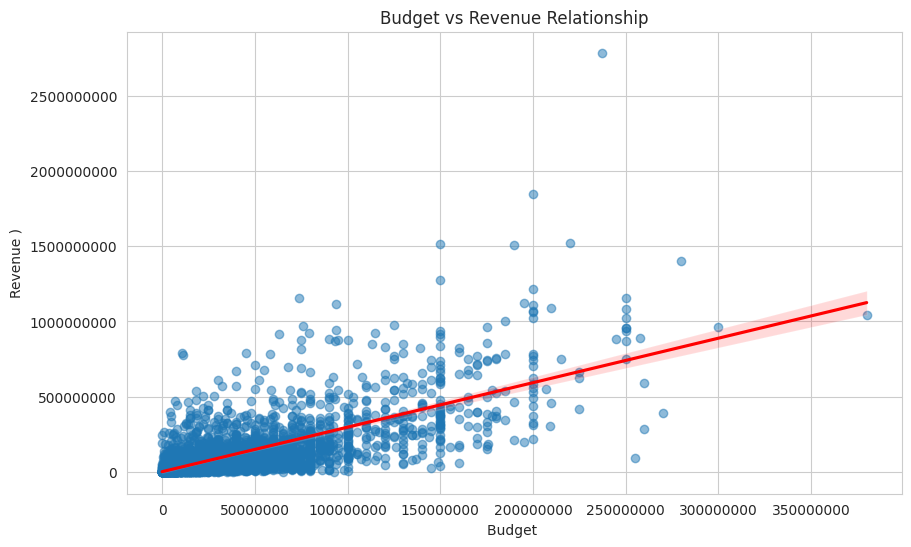

In [ ]:
plt.figure(figsize=(10,6))

sns.regplot(
    x=df["budget"],
    y=df["revenue"],
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.xlabel("Budget ")
plt.ylabel("Revenue )")
plt.title("Budget vs Revenue Relationship")

plt.ticklabel_format(style='plain')  # bilimsel gösterimi kaldırır
plt.show()


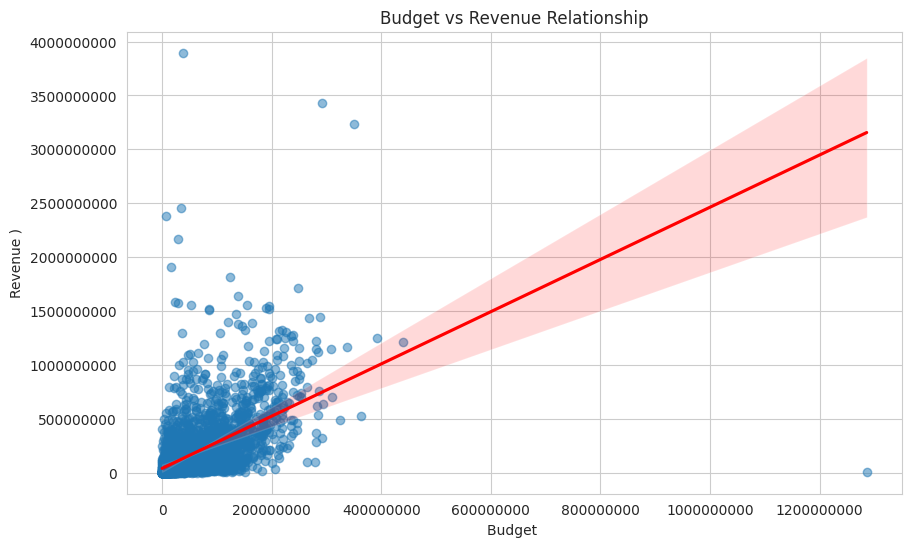

In [ ]:
plt.figure(figsize=(10,6))

sns.regplot(
    x=df["budget_adjusted"],
    y=df["revenue_adjusted"],
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.xlabel("Budget ")
plt.ylabel("Revenue )")
plt.title("Budget vs Revenue Relationship")

plt.ticklabel_format(style='plain')  # bilimsel gösterimi kaldırır
plt.show()


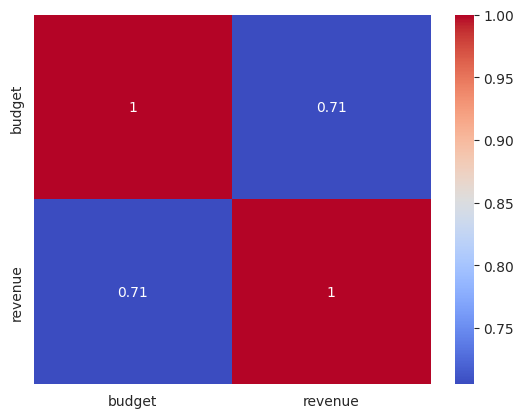

In [ ]:
sns.heatmap(df[["budget",  "revenue"]].corr(), annot=True, cmap="coolwarm")
plt.show()

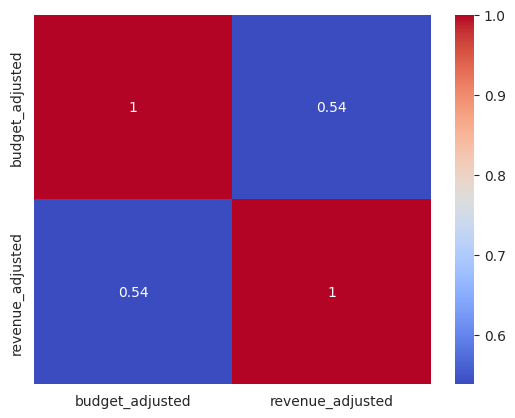

In [ ]:
sns.heatmap(df[["budget_adjusted",  "revenue_adjusted"]].corr(), annot=True, cmap="coolwarm")
plt.show()

“Enflasyon etkisi giderildiğinde bütçe ile gelir arasındaki korelasyonun azaldığı gözlemlenmiştir. Bu durum, nominal verilerde görülen güçlü ilişkinin kısmen enflasyon kaynaklı olduğunu ve gerçek ilişkinin daha sınırlı olduğunu göstermektedir. Bütçe, gişe başarısını etkileyen faktörlerden biri olmakla birlikte, tek başına belirleyici değildir.”

### Prodüksiyon Şirketi Puanı ve Gişe Geliri Arasındaki İlişki

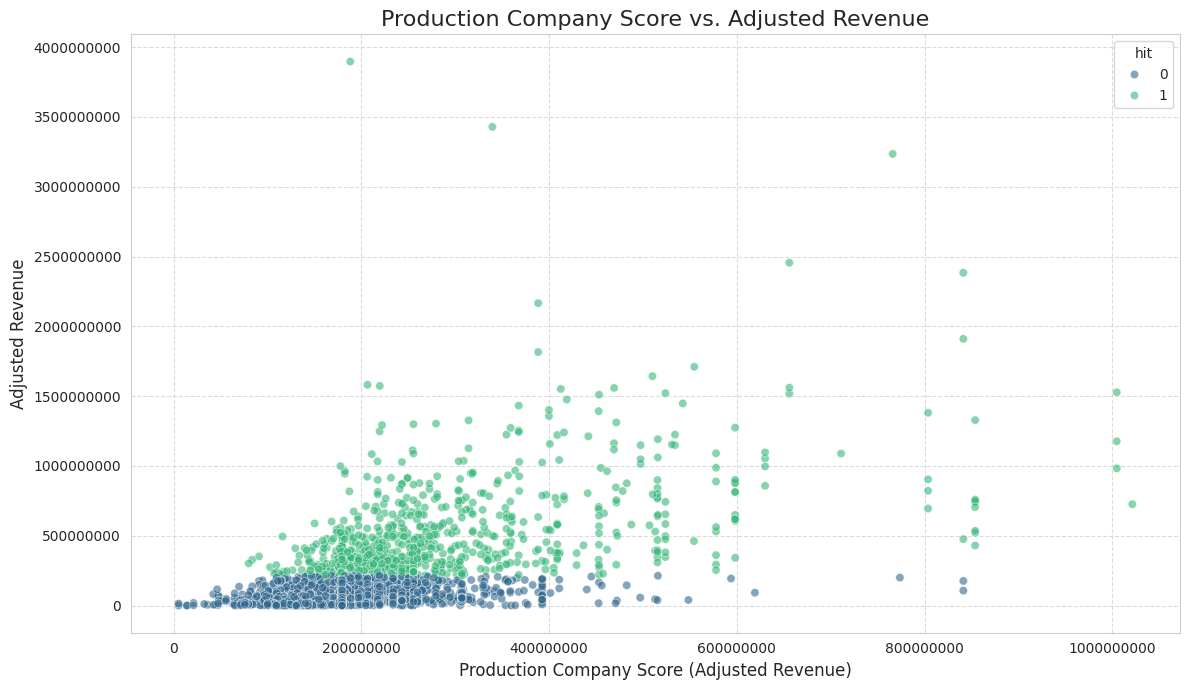

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x=df['production_company_score'],
    y=df['revenue_adjusted'],
    alpha=0.6,
    hue=df['hit'], # 'hit' filmleri farklı renkte göstererek daha fazla bilgi edinebiliriz
    palette='viridis'
)

plt.title('Production Company Score vs. Adjusted Revenue', fontsize=16)
plt.xlabel('Production Company Score (Adjusted Revenue)', fontsize=12)
plt.ylabel('Adjusted Revenue', fontsize=12)
plt.ticklabel_format(style='plain', axis='x') # Bilimsel gösterimi kapat
plt.ticklabel_format(style='plain', axis='y') # Bilimsel gösterimi kapat
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


--- Temel Bulgular ---
1. Prodüksiyon şirketi puanı ile düzeltilmiş gişe geliri arasında pozitif bir ilişki gözlemlenmektedir. Yüksek puanlı şirketlerin filmleri genellikle daha yüksek gişe geliri elde etmektedir.
2. Grafikte, 'hit' olarak işaretlenmiş (yani en çok kazanan %25'lik dilimdeki) filmlerin genellikle sağ üst köşede yoğunlaştığı, yani hem yüksek prodüksiyon şirketi puanına hem de yüksek gişe gelirine sahip olduğu görülmektedir.
3. Ancak, tek başına yüksek bir prodüksiyon şirketi puanının her zaman çok yüksek gişe geliri anlamına gelmediği, dağılımda belirli bir varyasyon olduğu da dikkat çekmektedir.
4. Bu ilişki, büyük ve köklü prodüksiyon şirketlerinin pazar gücünün ve pazarlama yeteneklerinin filmlerin başarısında önemli bir rol oynadığını göstermektedir.

### En Çok Gişe Başarısı Alanlar

In [ ]:
top_10_movies = df.sort_values(by='revenue_adjusted', ascending=False).head(10)
display(top_10_movies[['title', 'revenue_adjusted']])

,title,revenue_adjusted
2883,Gone with the Wind,"3,896,887,240"
0,Avatar,"3,428,845,398"
25,Titanic,"3,235,278,617"
2391,Star Wars,"2,455,706,410"
3143,Bambi,"2,383,376,223"
2429,E.T. the Extra-Terrestrial,"2,166,156,541"
3085,Snow White and the Seven Dwarfs,"1,910,458,114"
648,Jurassic Park,"1,815,896,949"
16,The Avengers,"1,710,275,815"
324,The Lord of the Rings: The Return of the King,"1,643,126,187"


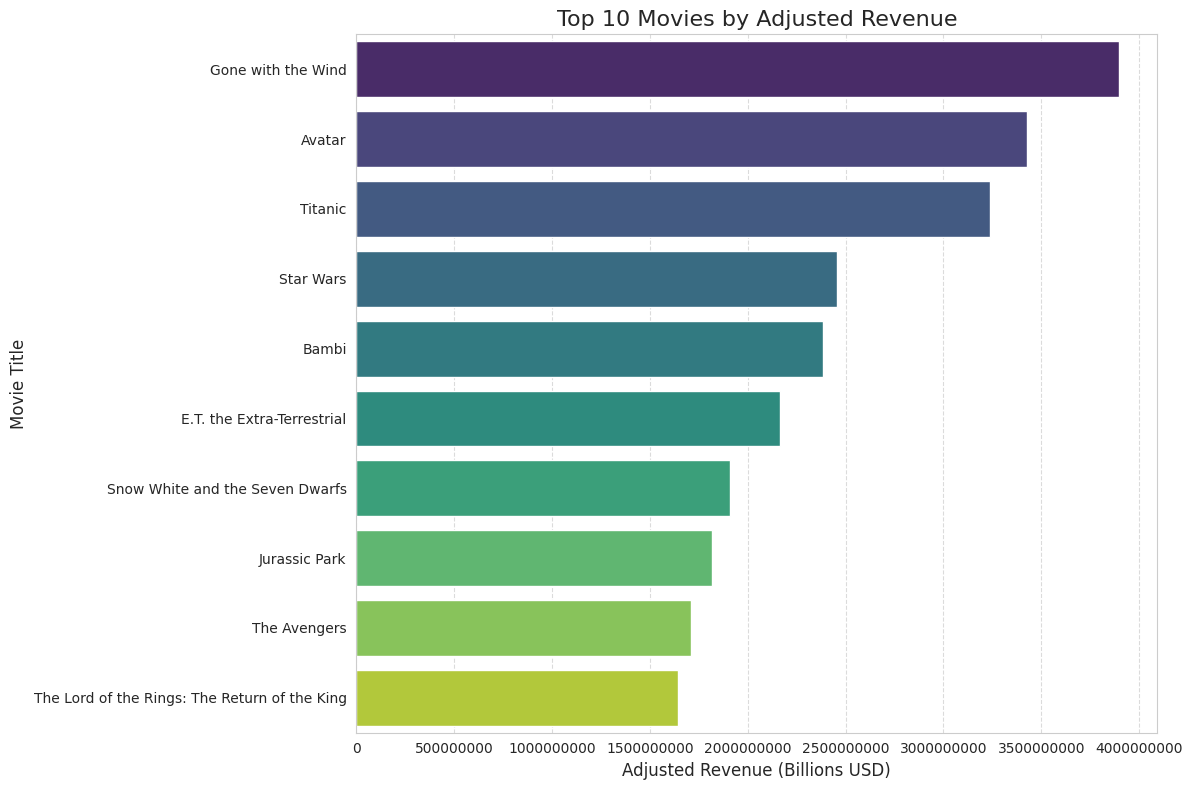


--- Temel Bulgular ---
1. 'Gone with the Wind', enflasyon düzeltmesi yapıldığında en yüksek gişe geliri elde eden film olarak öne çıkmaktadır.
2. Listede 'Avatar' ve 'Titanic' gibi modern gişe rekorları kıran filmler de yüksek sıralarda yer almaktadır, bu da onların zamanın testine dayanıklı başarılarını göstermektedir.
3. 'Star Wars' ve 'Bambi' gibi klasikleşmiş filmlerin de enflasyon düzeltilmiş gelirlerinin oldukça yüksek olması, uzun ömürlü popülerliklerini ve kültürel etkilerini vurgulamaktadır.
4. Grafikteki filmlerin gelirleri milyar dolar seviyelerindedir, bu da bu filmlerin finansal büyüklüğünü açıkça ortaya koymaktadır.


In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x='revenue_adjusted', y='title', data=top_10_movies, palette='viridis')
plt.title('Top 10 Movies by Adjusted Revenue', fontsize=16)
plt.xlabel('Adjusted Revenue (Billions USD)', fontsize=12)
plt.ylabel('Movie Title', fontsize=12)
plt.ticklabel_format(style='plain', axis='x') # Disable scientific notation for x-axis
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n--- Temel Bulgular ---")
print("1. 'Gone with the Wind', enflasyon düzeltmesi yapıldığında en yüksek gişe geliri elde eden film olarak öne çıkmaktadır.")
print("2. Listede 'Avatar' ve 'Titanic' gibi modern gişe rekorları kıran filmler de yüksek sıralarda yer almaktadır, bu da onların zamanın testine dayanıklı başarılarını göstermektedir.")
print("3. 'Star Wars' ve 'Bambi' gibi klasikleşmiş filmlerin de enflasyon düzeltilmiş gelirlerinin oldukça yüksek olması, uzun ömürlü popülerliklerini ve kültürel etkilerini vurgulamaktadır.")
print("4. Grafikteki filmlerin gelirleri milyar dolar seviyelerindedir, bu da bu filmlerin finansal büyüklüğünü açıkça ortaya koymaktadır.")

### En Çok Kar Ettiren Filmler


In [ ]:
top_10_profit_movies = df.sort_values(by="profit", ascending=False).head(10)
display(top_10_profit_movies[['title', 'director', 'profit','roi',"budget_adjusted","year"]])

,title,director,profit,roi,budget_adjusted,year
2883,Gone with the Wind,Victor Fleming,"3,857,935,551",100,"38,951,689",1939
0,Avatar,James Cameron,"3,137,365,292",12,"291,480,106",2009
25,Titanic,James Cameron,"2,884,577,406",9,"350,701,211",1997
2391,Star Wars,George Lucas,"2,420,869,114",70,"34,837,297",1977
3143,Bambi,David Hand,"2,375,730,089",312,"7,646,134",1942
2429,E.T. the Extra-Terrestrial,Steven Spielberg,"2,137,471,536",76,"28,685,006",1982
3085,Snow White and the Seven Dwarfs,David Hand,"1,895,081,273",124,"15,376,841",1937
648,Jurassic Park,Steven Spielberg,"1,691,560,999",15,"124,335,950",1993
2327,Jaws,Steven Spielberg,"1,557,830,577",67,"23,519,292",1975
2326,The Exorcist,William Friedkin,"1,544,527,021",55,"28,516,134",1973


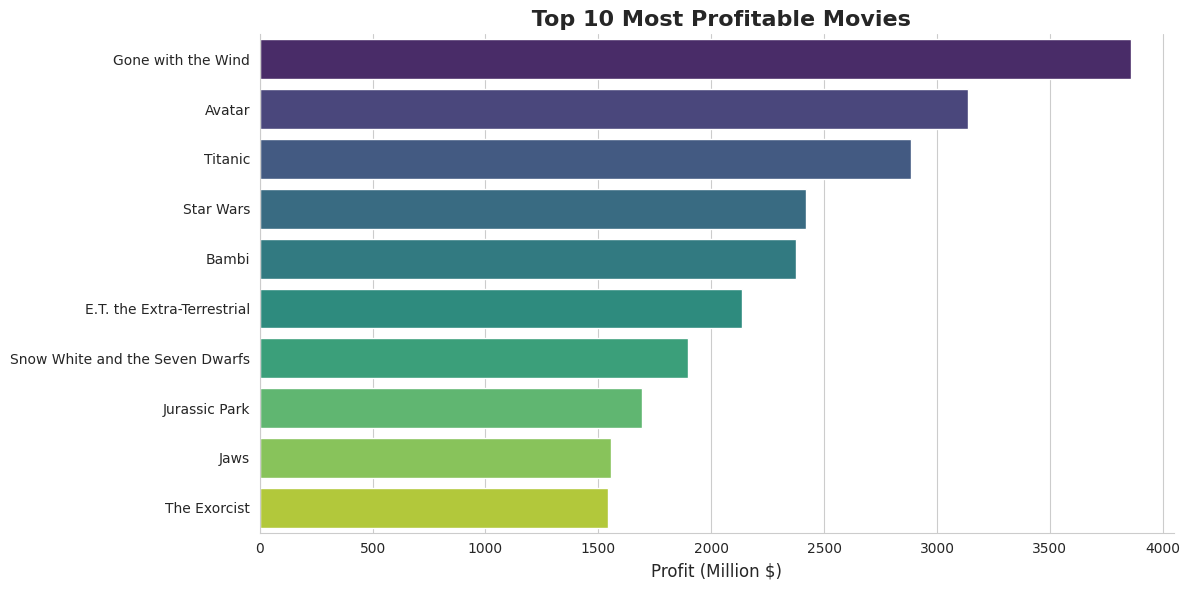

In [ ]:
top_10 = df.sort_values(by='profit', ascending=False).head(10)

plt.figure(figsize=(12,6))

# Profit'i milyon dolara çevir
top_10["profit_m"] = top_10["profit"] / 1e6

sns.barplot(
    x="profit_m",
    y="title",
    data=top_10,
    palette="viridis"
)

plt.xlabel("Profit (Million $)", fontsize=12)
plt.ylabel("")
plt.title(" Top 10 Most Profitable Movies", fontsize=16, weight='bold')


sns.despine()
plt.tight_layout()
plt.show()

### Büyük bütçeli filmler her zaman daha mı çok kar elde ediyor?

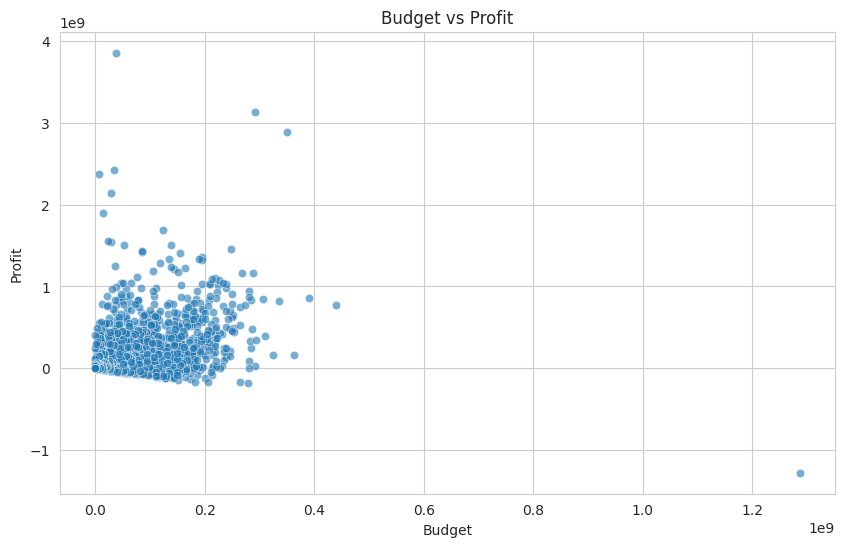

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["budget_adjusted"],
    y=df["profit"],
    alpha=0.6
)

plt.xlabel("Budget")
plt.ylabel("Profit")
plt.title("Budget vs Profit")

plt.show()

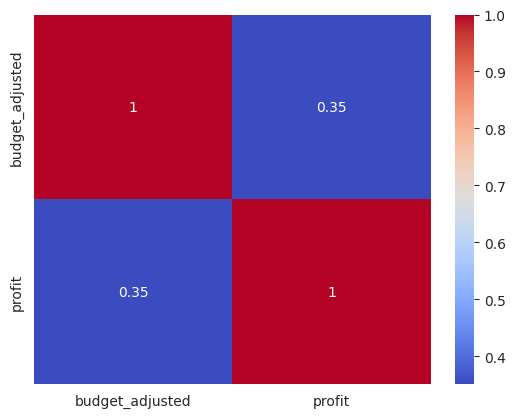

In [ ]:
sns.heatmap(df[["budget_adjusted","profit"]].corr(), annot=True, cmap="coolwarm")
plt.show( )

Bütçe, kârın güçlü bir belirleyicisi değildir; yüksek bütçeler daha yüksek kazanç potansiyeli sunarken aynı zamanda daha fazla belirsizlik ve risk içerir.
“Bütçe ile kâr arasında zayıf–orta düzeyde pozitif bir ilişki bulunmaktadır; ancak aynı bütçede farklı kâr seviyeleri gözlemlenmesi, bütçenin tek başına kârın güçlü bir belirleyicisi olmadığını göstermektedir. %35 etkiliyor”

### Heatmap

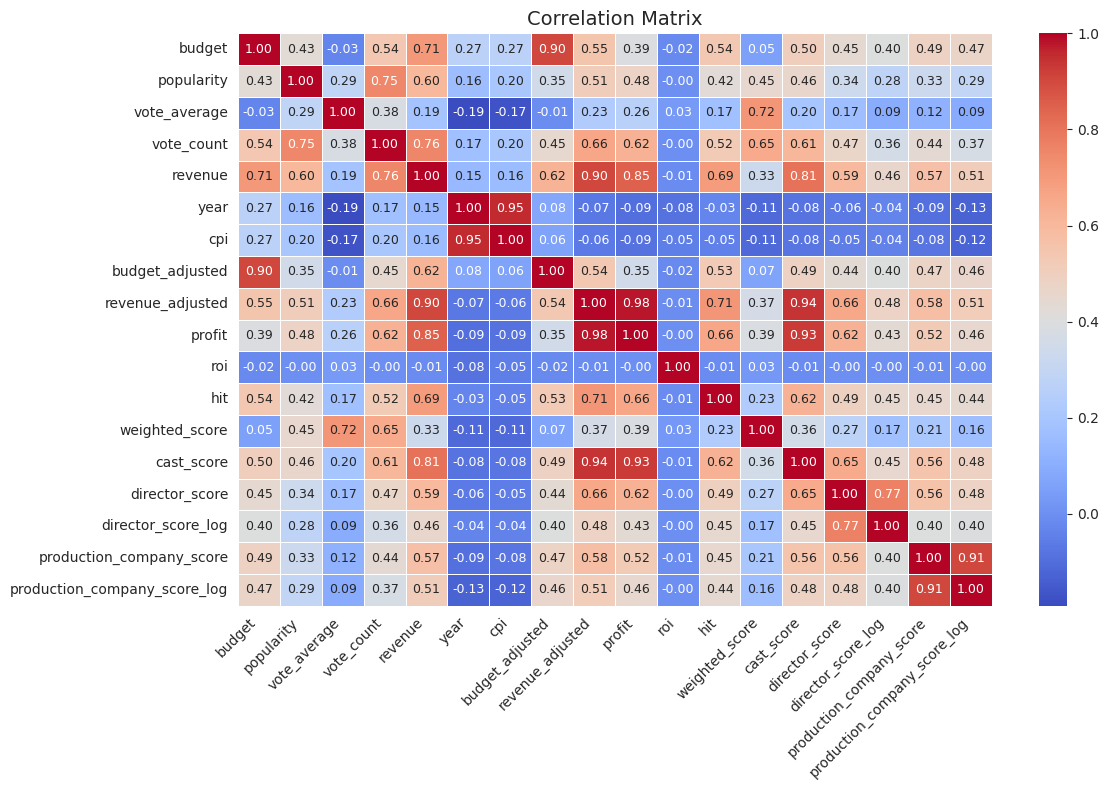

In [ ]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",           # daha kısa sayı
    cmap="coolwarm",
    linewidths=0.5,      # çizgi ekler
    annot_kws={"size":9} # yazı küçült
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

### Film rating’lerinin yüksek olması filmin gişe başarısını nasıl etkiliyor ?


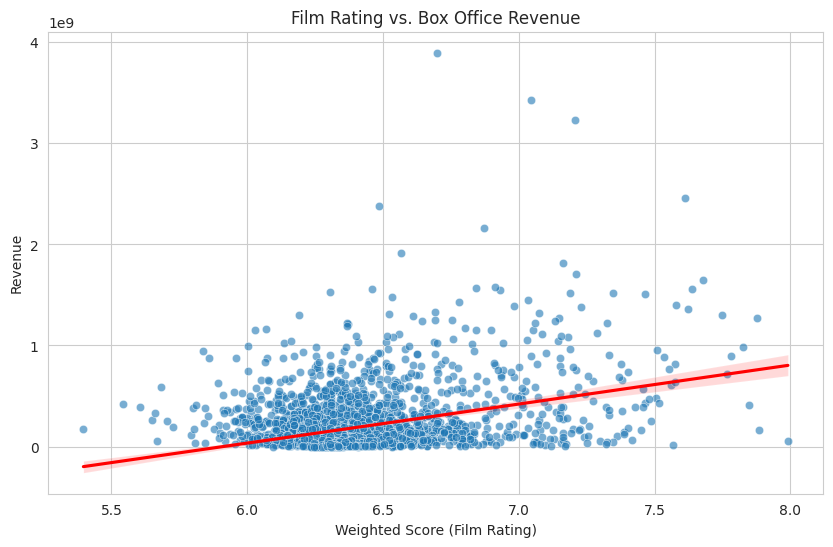

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=df["weighted_score"],
    y=df["revenue_adjusted"],
    alpha=0.6,

)
sns.regplot(
    x=df["weighted_score"],
    y=df["revenue_adjusted"],
    scatter=False,   # sadece çizgi
    color="red"
)

plt.xlabel("Weighted Score (Film Rating)")
plt.ylabel("Revenue")
plt.title("Film Rating vs. Box Office Revenue")
plt.show()

Film reytinglerinin yüksek olması gişeyi yukarı yönlü tetikler, ancak bu etki sanıldığı kadar devasa değildir. Gişe başarısını asıl sürükleyen şeyler; bütçe gücü, oyuncu kadrosunun piyasa değeri (cast_score) ve filmin ne kadar geniş bir kitleye yayıldığıdır

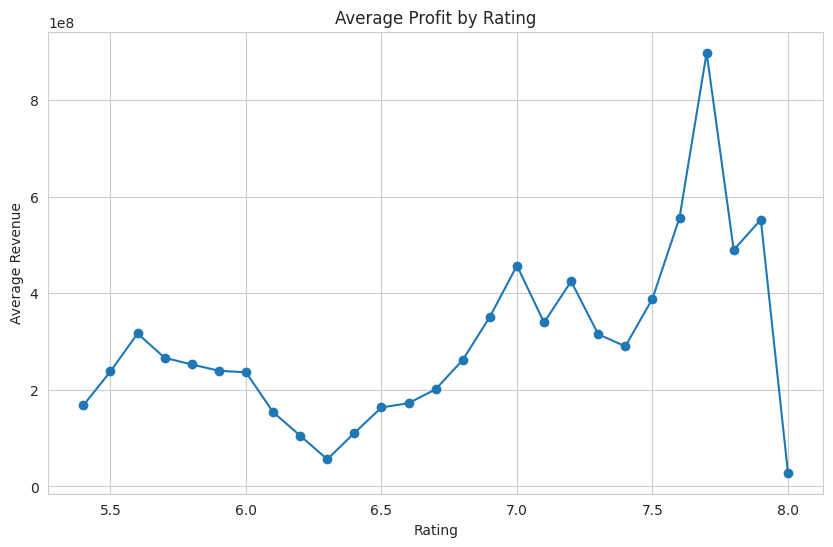

In [ ]:
df["rating_bin"] = df["weighted_score"].round(1)

grouped = df.groupby("rating_bin")["revenue"].mean()

plt.figure(figsize=(10,6))
grouped.plot(kind="line", marker="o")

plt.xlabel("Rating")
plt.ylabel("Average Revenue")
plt.title("Average Profit by Rating")

plt.grid(True)
plt.show()

“Film puanı ile gişe geliri arasında pozitif ancak doğrusal olmayan bir ilişki bulunmaktadır. Özellikle 7 ve üzeri puanlara sahip filmlerde gelir artışı belirginleşmektedir. Ancak yüksek puan tek başına gişe başarısını garanti etmemektedir.”

### Gişe Rekoru Kırmış Filmlerin Tür Dağılımı

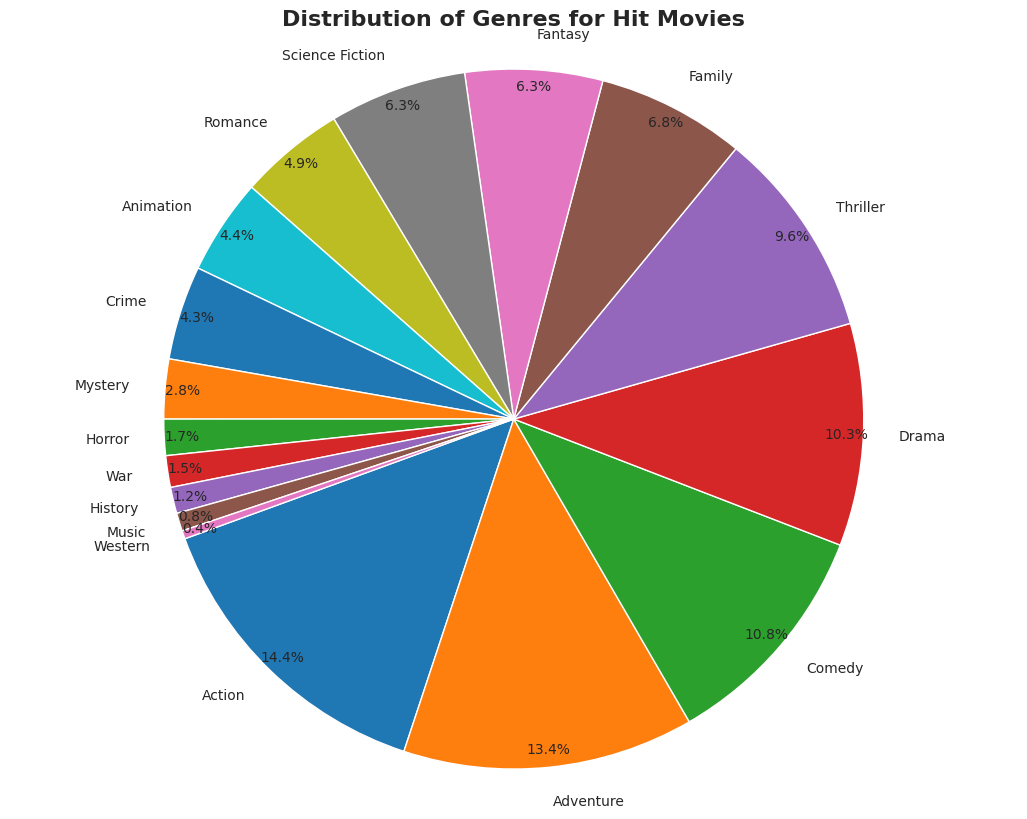

In [ ]:
hit_movies = df[df['hit'] == True]
exploded_genres = hit_movies['genres'].explode() #Türleri ayırıyorsun (explode)
genre_counts = exploded_genres.value_counts()

# Create the pie chart
plt.figure(figsize=(13, 10))
plt.pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%', startangle=200, pctdistance=0.95, textprops={'fontsize': 10})
plt.title('Distribution of Genres for Hit Movies', fontsize=16, weight='bold')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

“Hit filmler ağırlıklı olarak geniş kitlelere hit eden aksiyon, macera ve eğlence odaklı türlerde yoğunlaşmaktadır. Niş türlerin gişe başarısı elde etme olasılığı daha düşüktür.”

### Filmin türü gişe başarısını etkiliyor mu?

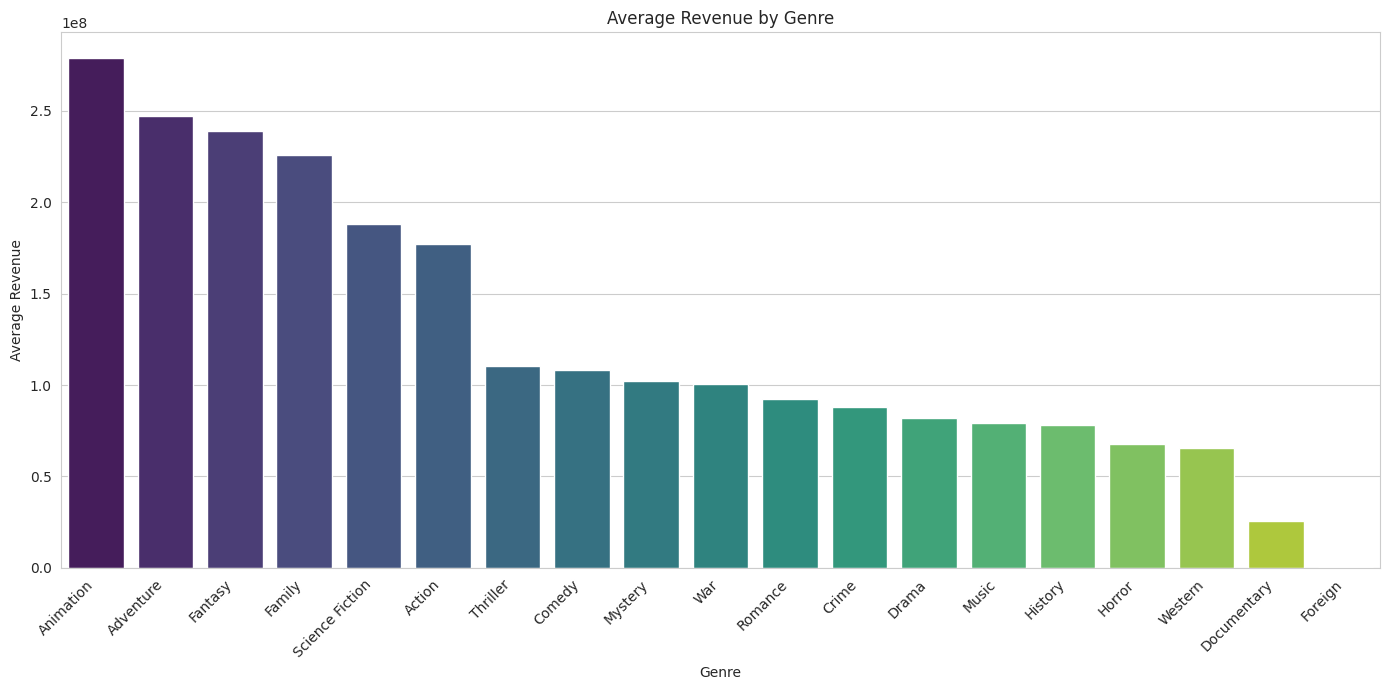

In [ ]:
# Explode the 'genres' column to have one genre per row
exploded_df = df.explode('genres')

# Calculate the average revenue for each genre
genre_revenue = exploded_df.groupby('genres')['revenue'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 7))
sns.barplot(x=genre_revenue.index, y=genre_revenue.values, palette='viridis')
plt.xlabel("Genre")
plt.ylabel("Average Revenue")
plt.title("Average Revenue by Genre")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

“Film türü ile gişe geliri arasında anlamlı bir ilişki bulunmaktadır. Özellikle geniş kitleye hit eden ve yüksek prodüksiyon içeren türler daha yüksek ortalama gelir üretmektedir.”

## Yıllara göre trend analizi

In [ ]:
df["year"] = pd.to_datetime(df["release_date"]).dt.year
pd.Series(df["year"].astype(int).unique()).sort_values()

,0
85,1916
88,1925
51,1927
86,1929
66,1930
...,...
3,2012
8,2013
10,2014
2,2015


<Axes: title={'center': 'Average Revenue Over Years'}, xlabel='year'>

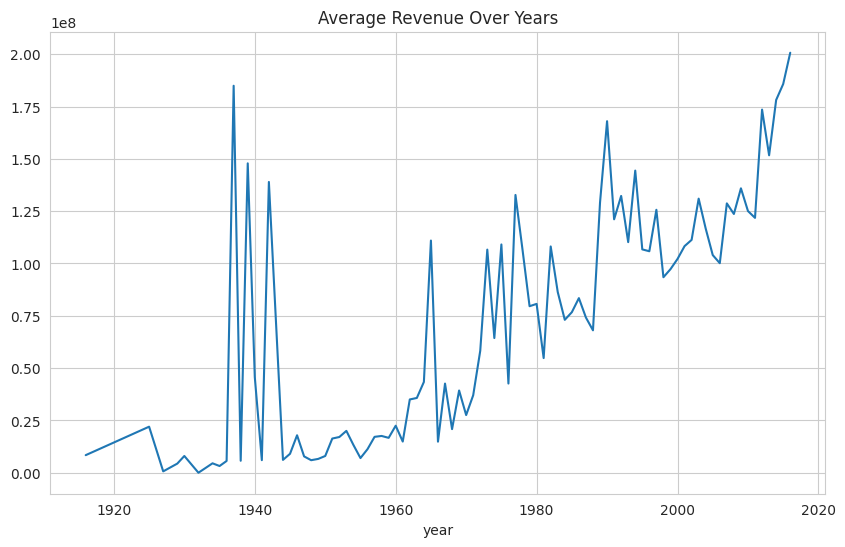

In [ ]:
yearly = df.groupby("year")["revenue"].mean()

yearly.plot(figsize=(10,6), title="Average Revenue Over Years")

Film endüstrisinde zamanla ortalama gişe gelirlerinin arttığı gözlemlenmektedir; ancak bu artış enflasyon, bütçe artışı ve global pazar genişlemesi gibi faktörlerden etkilenmiş olabilir.”

<Axes: title={'center': 'Average Revenue Over Years'}, xlabel='year'>

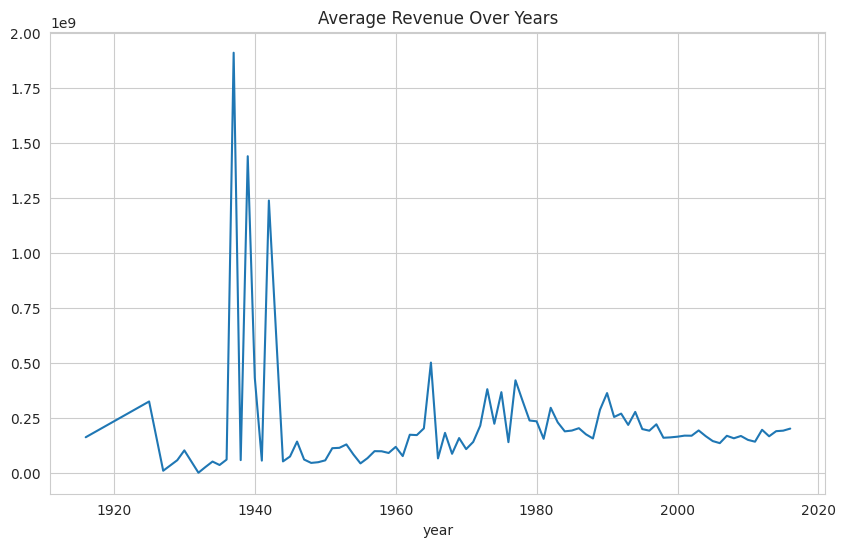

In [ ]:

yearly = df.groupby("year")["revenue_adjusted"].mean()

yearly.plot(figsize=(10,6), title="Average Revenue Over Years")

“Enflasyon düzeltmesi sonrasında, gişe gelirlerindeki artışın önemli ölçüde azaldığı ve sektörün reel anlamda daha sınırlı bir büyüme gösterdiği görülmektedir.”

## Aylara Göre Gelir Analizi

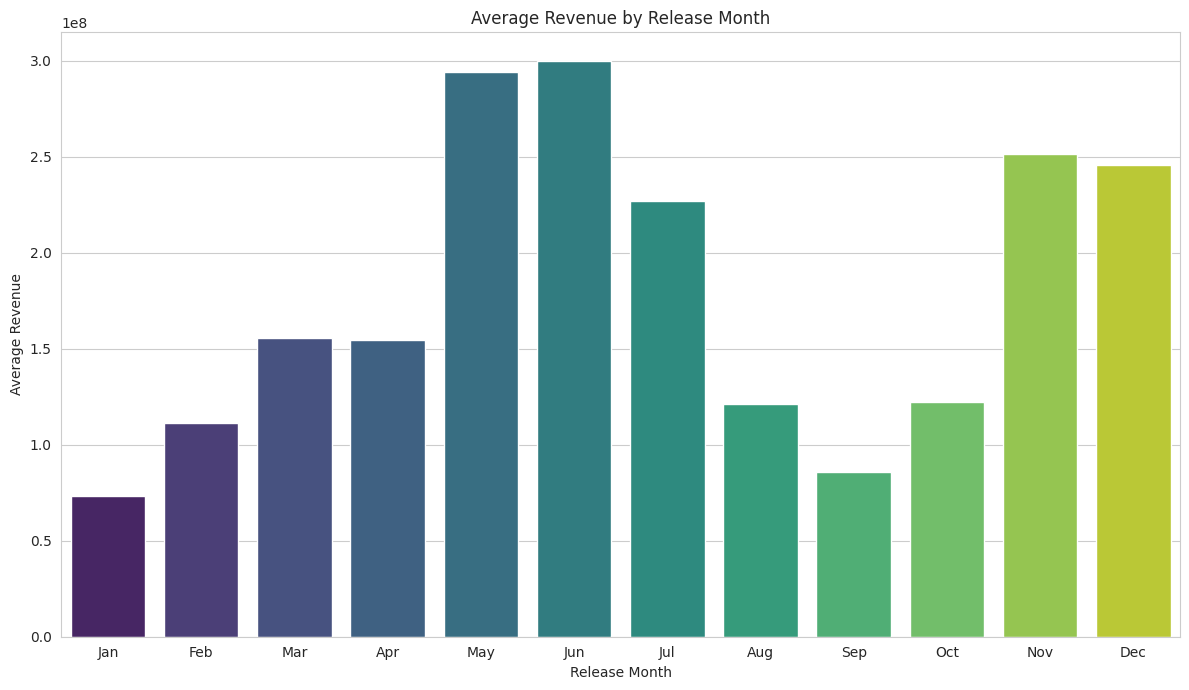

In [ ]:
df['release_month'] = pd.to_datetime(df['release_date']).dt.month

monthly_revenue = df.groupby('release_month')['revenue_adjusted'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='release_month', y='revenue_adjusted', data=monthly_revenue, palette='viridis')
plt.xlabel('Release Month')
plt.ylabel('Average Revenue')
plt.title('Average Revenue by Release Month')
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()
plt.show()

“Filmlerin gişe performansı yıl içinde mevsimsel bir dağılım göstermektedir. Özellikle yaz başlangıcı ve yıl sonu dönemleri ticari açıdan en verimli zaman dilimleri olarak öne çıkmaktadır.”

## Hangi yönetmenler para kazandırıyor?

In [ ]:
# 1. Aynı film tekrarlarını önle
df_director = df.drop_duplicates(subset=["title", "director"])

# 2. Minimum film sayısı filtresi (çok önemli)
director_counts = df_director["director"].value_counts()
valid_directors = director_counts[director_counts > 5].index

df_filtered = df_director[df_director["director"].isin(valid_directors)]

# 3. Metrikleri hesapla
director_hit = df_filtered.groupby("director")["hit"].mean()
director_median_revenue = df_filtered.groupby("director")["revenue_adjusted"].median()

# 4. Combine (en güçlü yapı)
director_summary = pd.DataFrame({
    "hit_rate": director_hit,
    "median_revenue": director_median_revenue,
    "movie_count": director_counts[valid_directors]
})

# 5. En iyi yönetmenler (hit rate’e göre)
top_directors = director_summary.sort_values(by="hit_rate", ascending=False).head(10)

top_directors

,hit_rate,median_revenue,movie_count
director,,,
Bryan Singer,1,"500,559,183",8
Wolfgang Petersen,1,"353,194,709",7
Robert Zemeckis,1,"399,996,628",13
Michael Bay,1,"652,515,980",12
Peter Jackson,1,"1,047,269,557",9
Chris Columbus,1,"729,756,173",9
Roland Emmerich,1,"367,583,076",8
Steven Spielberg,1,"532,604,490",27
Tom Shadyac,1,"232,571,761",7


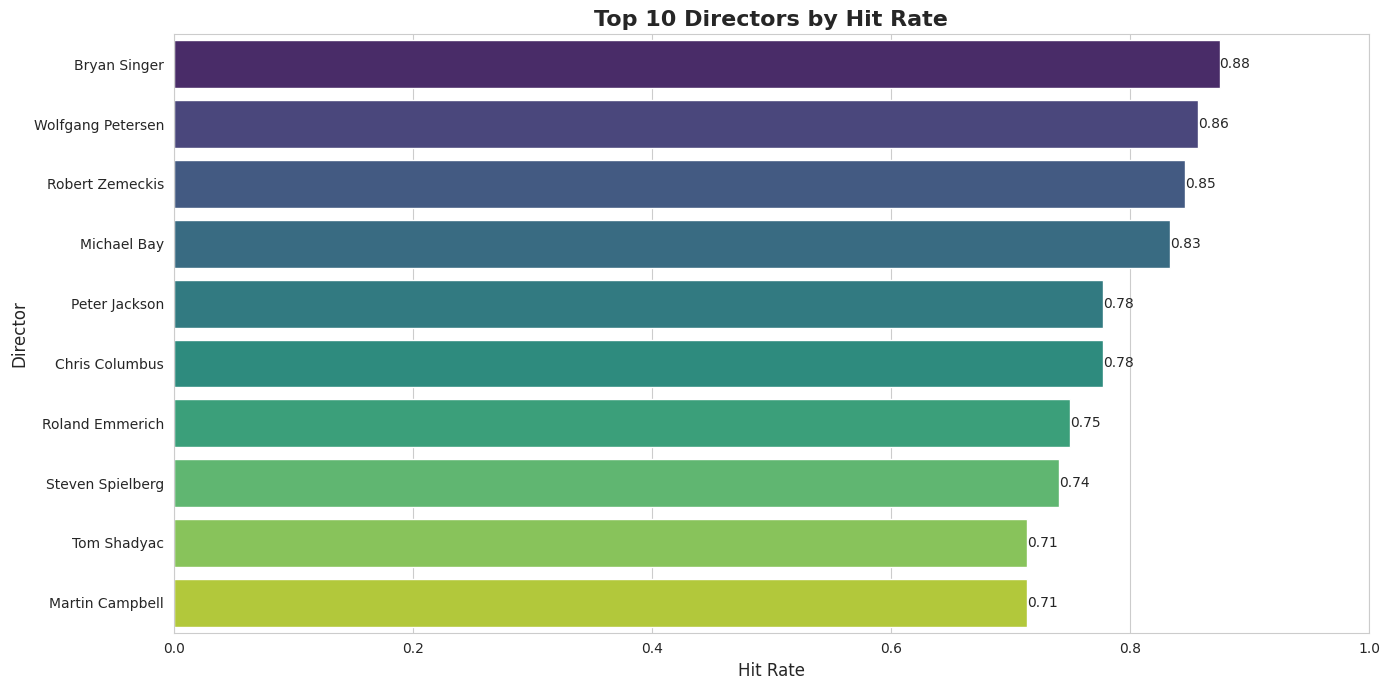

In [ ]:


plt.figure(figsize=(14,7))

sns.barplot(
    x=top_directors["hit_rate"],
    y=top_directors.index,
    palette="viridis"
)

plt.xlabel("Hit Rate", fontsize=12)
plt.ylabel("Director", fontsize=12)
plt.title("Top 10 Directors by Hit Rate", fontsize=16, weight='bold')

# Değerleri yaz
for i, v in enumerate(top_directors["hit_rate"]):
    plt.text(v, i, f"{v:.2f}", va='center')

plt.xlim(0,1)
plt.tight_layout()
plt.show()

“Yönetmen performansını daha güvenilir değerlendirmek amacıyla minimum film sayısı filtresi uygulanmış, ortalama yerine medyan gelir kullanılmış ve başarı oranını ölçmek için hit oranı metriği eklenmiştir.”

## Son 5 yıldaki en popüler yönetmenler

In [ ]:
last_available_year = df['year'].max()
start_year_filter = last_available_year - 4

df_recent = df[df['year'] >= start_year_filter]

print(f"Original DataFrame shape: {df.shape}")
print(f"Filtered DataFrame shape (last 5 years): {df_recent.shape}")
display(df_recent.head())

Original DataFrame shape: (3232, 27)
Filtered DataFrame shape (last 5 years): (618, 27)


,budget,popularity,vote_average,vote_count,genres,cast,crew,revenue,production_companies,release_date,title,year,cpi,budget_adjusted,revenue_adjusted,profit,roi,hit,weighted_score,cast_score,director,director_score,director_score_log,production_company_score,production_company_score_log,rating_bin,release_month
2,245000000,107,6,4466,"[Action, Adventure, Crime]","[Daniel Craig, Christoph Waltz, Léa Seydoux, R...",[Sam Mendes],880674609,"[Columbia Pictures, Danjaq, B24]",2015-10-26,Spectre,2015,187,"252,350,000","907,094,847","654,744,847",4,1,6,"771,528,357",Sam Mendes,"466,458,783",20,"305,221,305",20,6,10
3,250000000,112,8,9106,"[Action, Crime, Drama, Thriller]","[Christian Bale, Michael Caine, Gary Oldman, A...",[Christopher Nolan],1084939099,"[Legendary Pictures, Warner Bros., DC Entertai...",2012-07-16,The Dark Knight Rises,2012,171,"281,377,202","1,221,108,514","939,731,312",4,1,7,"807,644,245",Christopher Nolan,"637,095,870",20,"408,671,215",20,7,7
4,260000000,44,6,2124,"[Action, Adventure, Science Fiction]","[Taylor Kitsch, Lynn Collins, Samantha Morton,...",[Andrew Stanton],284139100,[Walt Disney Pictures],2012-03-07,John Carter,2012,171,"292,632,291","319,801,060","27,168,770",1,1,6,"274,950,993",Andrew Stanton,"744,880,414",20,"392,594,397",20,6,3
7,280000000,134,7,6767,"[Action, Adventure, Science Fiction]","[Robert Downey Jr., Chris Hemsworth, Mark Ruff...",[Joss Whedon],1405403694,"[Marvel Studios, Prime Focus, Revolution Sun S...",2015-04-22,Avengers: Age of Ultron,2015,187,"288,400,000","1,447,565,805","1,159,165,805",5,1,7,"992,326,181",Joss Whedon,"1,070,548,683",21,"542,408,070",20,7,4
9,250000000,156,6,7004,"[Action, Adventure, Fantasy]","[Ben Affleck, Henry Cavill, Gal Gadot, Amy Ada...",[Zack Snyder],873260194,"[DC Comics, Atlas Entertainment, Warner Bros.,...",2016-03-23,Batman v Superman: Dawn of Justice,2016,192,"250,000,000","873,260,194","623,260,194",3,1,6,"671,110,047",Zack Snyder,"401,521,776",20,"344,630,211",20,6,3


In [ ]:
top_10_recent_directors = df_recent.groupby('director')['revenue_adjusted'].mean().sort_values(ascending=False).head(10)
display(top_10_recent_directors)

,revenue_adjusted
director,
Joss Whedon,"1,578,920,810"
Chris Buck,"1,392,373,515"
Shane Black,"1,328,144,098"
Kyle Balda,"1,191,432,891"
Sam Mendes,"1,077,395,017"
Peter Jackson,"1,070,257,337"
Pierre Coffin,"1,060,777,722"
Christopher Nolan,"968,671,670"
Jon Favreau,"966,550,600"


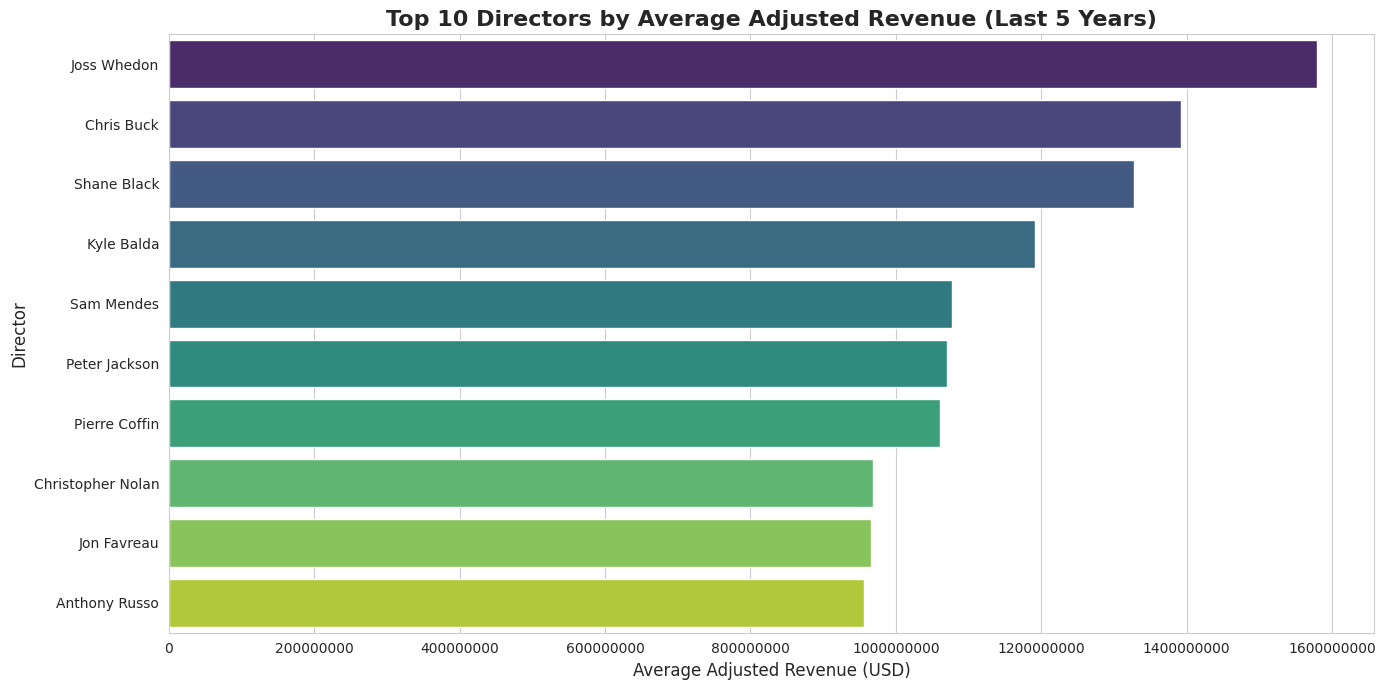

In [ ]:
plt.figure(figsize=(14, 7))
sns.barplot(x=top_10_recent_directors.values, y=top_10_recent_directors.index, palette="viridis")
plt.xlabel("Average Adjusted Revenue (USD)", fontsize=12)
plt.ylabel("Director", fontsize=12)
plt.title("Top 10 Directors by Average Adjusted Revenue (Last 5 Years)", fontsize=16, weight='bold')
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

## en yüksek gişe başarısına sahip oyuncular

In [ ]:
# 1. explode
df_cast = df.explode("cast")

# 2. aynı film + oyuncu tekrarlarını kaldır
df_cast = df_cast.drop_duplicates(subset=["title", "cast"])

# 3. minimum film sayısı filtresi
actor_counts = df_cast["cast"].value_counts()
valid_actors = actor_counts[actor_counts > 10].index  # 5 → 10 yaptık

df_cast_filtered = df_cast[df_cast["cast"].isin(valid_actors)]

# 4. hit oranı (EN DOĞRU METRİK)
actor_hit = df_cast_filtered.groupby("cast")["hit"].mean()

# 5. median revenue (outlier etkisini azaltır)
actor_revenue = df_cast_filtered.groupby("cast")["revenue"].median()

# 6. combine (çok güçlü analiz)
actor_summary = pd.DataFrame({
    "hit_rate": actor_hit,
    "median_revenue": actor_revenue,
    "movie_count": actor_counts[valid_actors]
})

# 7. en iyi oyuncular (hit rate'e göre)
top_actors = actor_summary.sort_values(by="hit_rate", ascending=False).head(10)

top_actors

,hit_rate,median_revenue,movie_count
cast,,,
Bernard Lee,1,"116,019,547",11
Jess Harnell,1,"722,404,431",14
Desmond Llewelyn,1,"156,167,015",17
Lois Maxwell,1,"124,881,062",15
Stan Lee,1,"648,338,422",26
Chris Miller,1,"532,680,671",11
John Ratzenberger,1,"529,855,930",22
Danny Mann,1,"365,207,690",14
Timothy Spall,1,"414,211,549",13


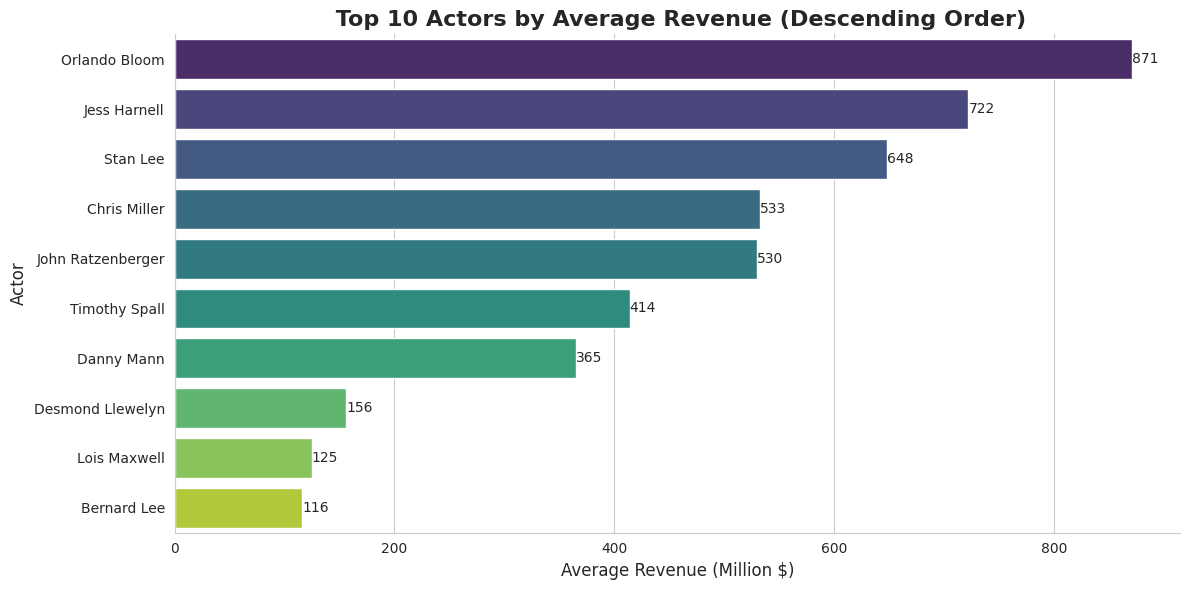

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_actors.sort_values(by='median_revenue', ascending=False)['median_revenue'] / 1e6,   # milyon $ olarak
    y=top_actors.sort_values(by='median_revenue', ascending=False).index,
    palette="viridis"
)

plt.xlabel("Average Revenue (Million $)", fontsize=12)
plt.ylabel("Actor", fontsize=12)
plt.title(" Top 10 Actors by Average Revenue (Descending Order)", fontsize=16, weight='bold')

# Değerleri yaz
for i, v in enumerate(top_actors.sort_values(by='median_revenue', ascending=False)['median_revenue'].values / 1e6):
    plt.text(v, i, f"{v:.0f}", va='center')

sns.despine()
plt.tight_layout()
plt.show()

“Analiz sonucunda bazı oyuncuların yüksek ortalama gişe gelirine sahip olduğu görülmektedir. Ancak bu durum, oyuncuların bireysel performansından ziyade, yer aldıkları yüksek hasılatlı film serilerinin etkisinden kaynaklanmaktadır.”

# MODEL

In [ ]:
df.columns

Index(['budget', 'popularity', 'vote_average', 'vote_count', 'genres', 'cast', 'crew', 'revenue', 'production_companies', 'release_date', 'title', 'year', 'cpi', 'budget_adjusted', 'revenue_adjusted', 'profit', 'roi', 'hit', 'weighted_score', 'cast_score', 'director', 'director_score', 'director_score_log', 'production_company_score', 'production_company_score_log', 'rating_bin', 'release_month'], dtype='object')

<Axes: >

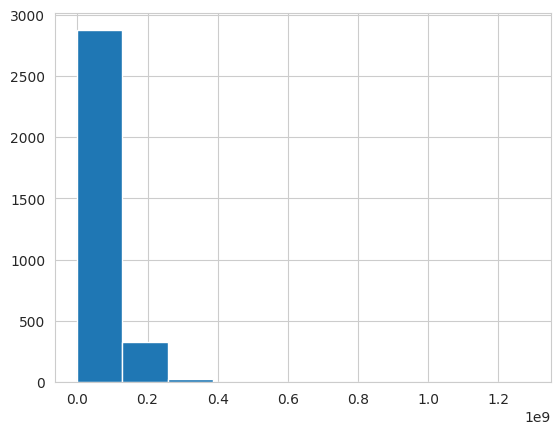

In [ ]:
df["budget_adjusted"].hist()

In [ ]:
df["budget_log"] = np.log1p(df["budget_adjusted"])

<Axes: >

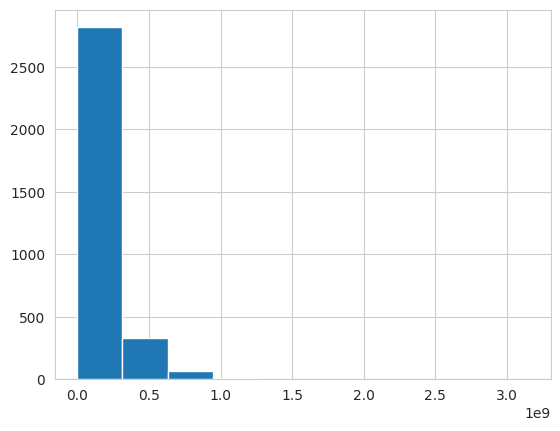

In [ ]:
df["cast_score"].hist()

### Genres Sütununu Kategorik Hale Getirme (One-Hot Encoding)

`genres` sütunu şu anda bir liste formatında olduğu için, makine öğrenimi modellerinde doğrudan kullanılamaz. Bu nedenle, her bir benzersiz türü ayrı bir sütuna dönüştürerek One-Hot Encoding uygulayacağız. Bu sayede her filmin hangi türlere ait olduğu sayısal olarak ifade edilecektir.

In [ ]:
# Check if the 'genres' column exists before processing
if 'genres' in df.columns:
    # Tüm benzersiz türleri topla
    all_genres = []
    for genres_list in df['genres']:
        all_genres.extend(genres_list)
    unique_genres = list(set(all_genres))

    # Her bir tür için yeni bir sütun oluştur ve one-hot encoding uygula
    for genre in unique_genres:
        df[genre] = df['genres'].apply(lambda x: 1 if genre in x else 0)

    # Orjinal 'genres' sütununu kaldır
    df = df.drop(columns=['genres'])
    print("Genres column successfully one-hot encoded and original column dropped.")
else:
    print("Genres column not found or already processed. Skipping one-hot encoding for genres.")

display(df.head(1))

Genres column successfully one-hot encoded and original column dropped.


,budget,popularity,vote_average,vote_count,cast,crew,revenue,production_companies,release_date,title,year,cpi,budget_adjusted,revenue_adjusted,profit,roi,hit,weighted_score,cast_score,director,director_score,director_score_log,production_company_score,production_company_score_log,rating_bin,release_month,budget_log,Thriller,Adventure,Romance,Fantasy,Animation,War,Foreign,History,Family,Mystery,Comedy,Drama,Science Fiction,Action,Crime,Horror,Music,Documentary,Western
0,237000000,150,7,11800,"[Sam Worthington, Zoe Saldana, Sigourney Weave...",[James Cameron],2787965087,"[Ingenious Film Partners, Twentieth Century Fo...",2009-12-10,Avatar,2009,156,"291,480,106","3,428,845,398","3,137,365,292",12,1,7,"2,512,560,125",James Cameron,"1,332,221,732",21,"339,537,694",20,7,12,19,0,1,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0


### month_dummies oluşturma

In [ ]:
month_dummies = pd.get_dummies(df["release_month"], prefix='release_month', dtype=int) # Ensure dummies are int
df = pd.concat([df, month_dummies], axis=1)

In [ ]:
df.head(1)

,budget,popularity,vote_average,vote_count,cast,crew,revenue,production_companies,release_date,title,year,cpi,budget_adjusted,revenue_adjusted,profit,roi,hit,weighted_score,cast_score,director,director_score,director_score_log,production_company_score,production_company_score_log,rating_bin,release_month,budget_log,Thriller,Adventure,Romance,Fantasy,Animation,War,Foreign,History,Family,Mystery,Comedy,Drama,Science Fiction,Action,Crime,Horror,Music,Documentary,Western,release_month_1,release_month_2,release_month_3,release_month_4,release_month_5,release_month_6,release_month_7,release_month_8,release_month_9,release_month_10,release_month_11,release_month_12
0,237000000,150,7,11800,"[Sam Worthington, Zoe Saldana, Sigourney Weave...",[James Cameron],2787965087,"[Ingenious Film Partners, Twentieth Century Fo...",2009-12-10,Avatar,2009,156,"291,480,106","3,428,845,398","3,137,365,292",12,1,7,"2,512,560,125",James Cameron,"1,332,221,732",21,"339,537,694",20,7,12,19,0,1,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [ ]:
# --- 1. VERİ TEMİZLİĞİ VE HAZIRLIK ---
# Sütunları temizle (Mükerrer isimli sütunları siler)
df = df.loc[:, ~df.columns.duplicated()]

# Bağımsız değişkenleri gruplandır
genre_columns = [
    'Family', 'War', 'Mystery', 'Documentary', 'Comedy', 'Western', 'Romance',
    'Crime', 'Music', 'Fantasy', 'Thriller', 'Animation', 'Science Fiction',
    'Action', 'Horror', 'History', 'Adventure', 'Foreign', 'Drama'
]
month_columns = [col for col in df.columns if col.startswith('release_month_')]
base_columns = ['budget_log', 'director_score', 'cast_score']

# X ve y oluşturma
X = df[base_columns + genre_columns + month_columns]
y = df['hit']

# Veriyi bölme (%80 Eğitim, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Sinir Ağları (MLP) ve bazı modeller için veriyi ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### RandomForestClassifier

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

--- MODEL PERFORMANS RAPORU ---
Accuracy (Doğruluk): %92.58

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.95      0.96      0.95       485
           1       0.87      0.83      0.85       162

    accuracy                           0.93       647
   macro avg       0.91      0.90      0.90       647
weighted avg       0.93      0.93      0.93       647



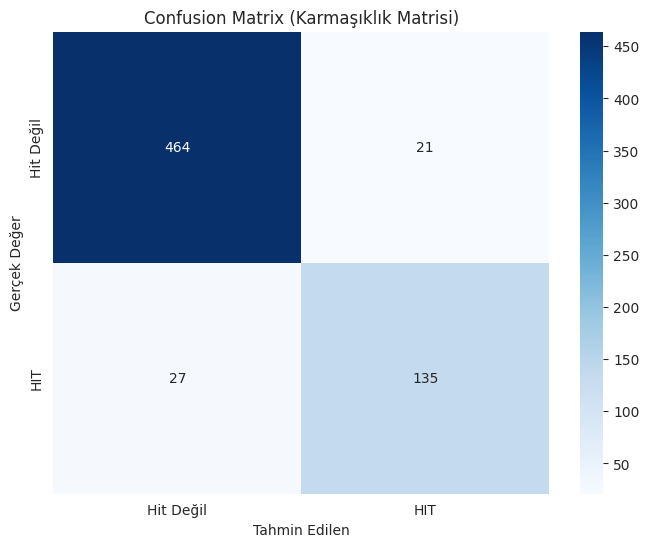

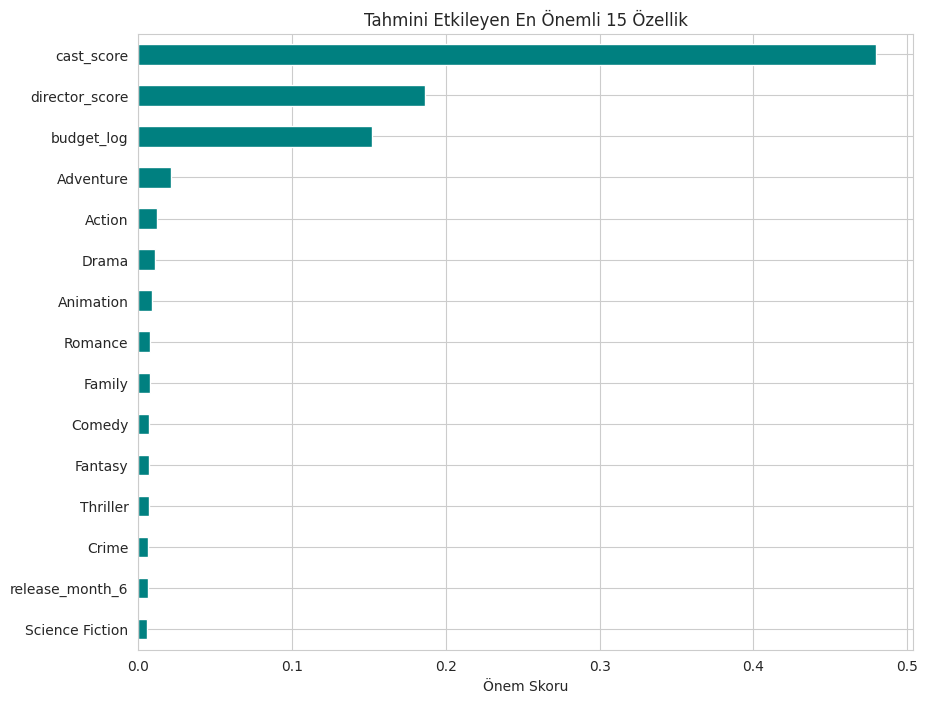

In [ ]:
# Sonuçları Yazdır
print("--- MODEL PERFORMANS RAPORU ---")
print(f"Accuracy (Doğruluk): %{accuracy_score(y_test, y_pred)*100:.2f}")
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred))

# --- 5. Görselleştirme: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Hit Değil', 'HIT'],
            yticklabels=['Hit Değil', 'HIT'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Confusion Matrix (Karmaşıklık Matrisi)')
plt.show()

# --- 6. Görselleştirme: Feature Importance (Özellik Önemi) ---
# Hangi değişkenin tahminde ne kadar etkili olduğunu gösterir
importances = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 8))
importances.nlargest(15).sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title('Tahmini Etkileyen En Önemli 15 Özellik')
plt.xlabel('Önem Skoru')
plt.show()

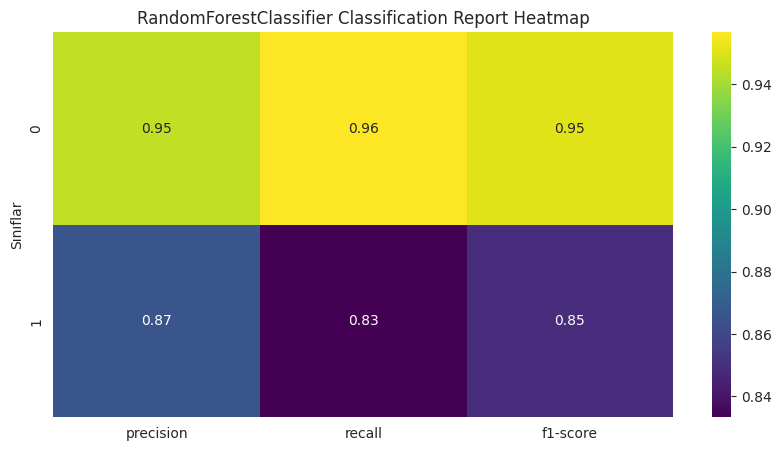

In [ ]:


# --- Görselleştirme: Classification Report (RandomForestClassifier) ---
report_rf = classification_report(y_test, y_pred, output_dict=True)

# DataFrame'e çevir
report_df_rf = pd.DataFrame(report_rf).transpose()

# accuracy, macro avg ve weighted avg satırlarını ayır
summary_rows_rf = report_df_rf.loc[['accuracy', 'macro avg', 'weighted avg']]
report_df_rf = report_df_rf.drop(labels=['accuracy', 'macro avg', 'weighted avg'])

plt.figure(figsize=(10, 5))
sns.heatmap(report_df_rf[['precision', 'recall', 'f1-score']], annot=True, cmap='viridis', fmt='.2f')
plt.title('RandomForestClassifier Classification Report Heatmap')
plt.ylabel('Sınıflar')
plt.show()



#### Sample

In [ ]:
def skoru_getir(isim, tip="director"):
    """
    Kullanıcının girdiği ismin veri setindeki başarı skorunu döndürür.
    İsim bulunamazsa genel ortalamayı döndürür.
    """
    if tip == "director":
        # Yönetmen ismini ara
        if isim in df['director'].values:
            return df[df['director'] == isim]['director_score'].iloc[0]
        else:
            return df['director_score'].mean() # Bilinmiyorsa ortalama ver

    elif tip == "cast":
        # Oyuncunun skorunu (cast_score içinden veya oyuncu bazlı tablodan) getir
        # Burada basitlik için en yüksek hasılatlı oyuncu tablonu kullanabilirsin
        if isim in actor_avg_revenue_adjusted.index:
            return actor_avg_revenue_adjusted[isim]
        else:
            return df['cast_score'].mean()

In [ ]:
print("--- Film Başarı Tahmin Sistemi ---")

# 1. Kullanıcıdan Girdileri Al
film_adi = input("Film Adı: ")
butce = float(input("Bütçe ($): "))
vizyon_ayi = int(input("Vizyon Ayı (1-12): "))
yonetmen_adi = input("Yönetmen İsmi: ")
basrol_adi = input("Başrol Oyuncusu İsmi: ")
secilen_turler = input("Türler (Virgülle ayırın, örn: Action, Drama): ").split(", ")

# 2. İsimleri Skorlara Dönüştür
y_skoru = skoru_getir(yonetmen_adi, tip="director")
o_skoru = skoru_getir(basrol_adi, tip="cast")

# 3. Modelin Beklediği Formatı Hazırla (Sample Prediction)
def tahmin_motoru(butce, ay, turler, d_score, c_score):
    # Boş şablon oluştur
    input_data = pd.DataFrame(0, index=[0], columns=X.columns)

    # Değerleri yerleştir
    input_data['budget_log'] = np.log1p(butce)
    input_data['director_score'] = d_score
    input_data['cast_score'] = c_score

    if f'release_month_{ay}' in input_data.columns:
        input_data[f'release_month_{ay}'] = 1

    for t in turler:
        if t in input_data.columns:
            input_data[t] = 1

    # Tahmin yap
    olasilik = model.predict_proba(input_data)[0][1]
    return olasilik

# 4. Sonucu Yazdır
basari_sansi = tahmin_motoru(butce, vizyon_ayi, secilen_turler, y_skoru, o_skoru)

print(f"\n Analiz Sonucu: '{film_adi}'")
print(f"Yönetmen: {yonetmen_adi} (Skor: {y_skoru:,.0f})")
print(f"Oyuncu: {basrol_adi} (Skor: {o_skoru:,.0f})")
print(f"---")
print(f"Bu filmin GIŞE REKORTMENİ olma ihtimali: %{basari_sansi * 100:.2f}")

if basari_sansi > 0.7:
    print("Sonuç: Bu film kesinlikle bir HIT adayı!")
elif basari_sansi > 0.4:
    print("Sonuç: Ortalama bir performans sergileyebilir.")
else:
    print("Sonuç: Gişede riskli görünüyor.")

--- Film Başarı Tahmin Sistemi ---
Film Adı: Fuze
Bütçe ($): 20000000
Vizyon Ayı (1-12): 5
Yönetmen İsmi: David Mackenzie
Başrol Oyuncusu İsmi: Sam Worthington
Türler (Virgülle ayırın, örn: Action, Drama): Action

 Analiz Sonucu: 'Fuze'
Yönetmen: David Mackenzie (Skor: 203,034,530)
Oyuncu: Sam Worthington (Skor: 489,974,219)
---
Bu filmin GIŞE REKORTMENİ olma ihtimali: %79.00
Sonuç: Bu film kesinlikle bir HIT adayı!


## XGBoost

In [ ]:
# 1. Aynı isme sahip mükerrer sütunları temizle (Sadece ilkini tutar)
df = df.loc[:, ~df.columns.duplicated()]

# 2. X ve y değişkenlerini temizlenmiş df üzerinden tekrar oluştur
genre_columns = [
    'Family', 'War', 'Mystery', 'Documentary', 'Comedy', 'Western', 'Romance',
    'Crime', 'Music', 'Fantasy', 'Thriller', 'Animation', 'Science Fiction',
    'Action', 'Horror', 'History', 'Adventure', 'Foreign', 'Drama'
]
month_columns = [col for col in df.columns if col.startswith('release_month_')]
base_columns = ['budget_log', 'director_score', 'cast_score']

X = df[base_columns + genre_columns + month_columns]
y = df['hit']

# 3. Veriyi tekrar böl
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. XGBoost'u şimdi çalıştır
from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

# Tahmin yap
y_pred_xgb = xgb_model.predict(X_test)
print("Başarıyla eğitildi!")

Başarıyla eğitildi!


In [ ]:
print("--- XGBoost Raporu ---")
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test,y_pred_xgb))
print(accuracy_score(y_test, y_pred_xgb))

--- XGBoost Raporu ---
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       485
           1       0.86      0.82      0.84       162

    accuracy                           0.92       647
   macro avg       0.90      0.89      0.90       647
weighted avg       0.92      0.92      0.92       647

[[464  21]
 [ 29 133]]
0.9227202472952086


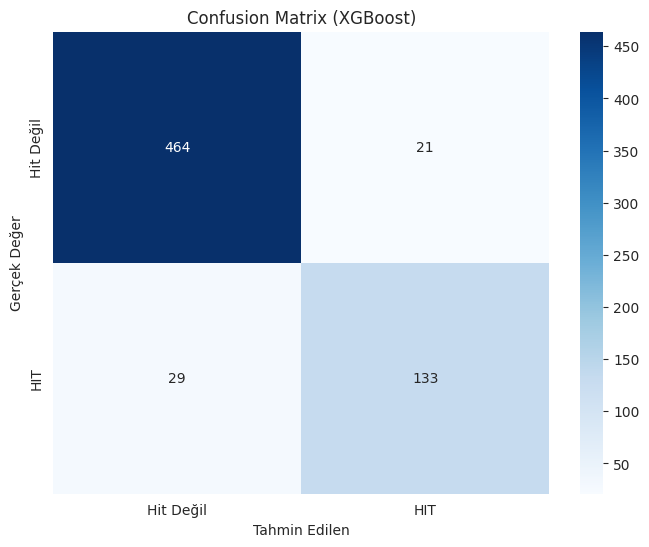

In [ ]:


# --- Görselleştirme: Confusion Matrix (XGBoost) ---
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Hit Değil', 'HIT'],
            yticklabels=['Hit Değil', 'HIT'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Confusion Matrix (XGBoost)')
plt.show()

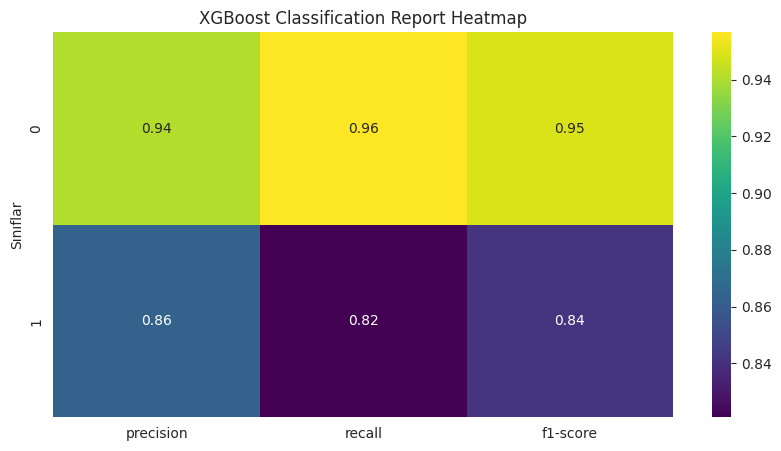

In [ ]:
# --- Görselleştirme: Classification Report (XGBoost) ---
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)

# DataFrame'e çevir
report_df_xgb = pd.DataFrame(report_xgb).transpose()

# accuracy, macro avg ve weighted avg satırlarını ayır
summary_rows_xgb = report_df_xgb.loc[['accuracy', 'macro avg', 'weighted avg']]
report_df_xgb = report_df_xgb.drop(labels=['accuracy', 'macro avg', 'weighted avg'])

plt.figure(figsize=(10, 5))
sns.heatmap(report_df_xgb[['precision', 'recall', 'f1-score']], annot=True, cmap='viridis', fmt='.2f')
plt.title('XGBoost Classification Report Heatmap')
plt.ylabel('Sınıflar')
plt.show()


## LightGBM

In [ ]:

lgbm_model = LGBMClassifier(n_estimators=100, class_weight='balanced', random_state=42)
lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)
print("--- LightGBM Raporu ---")
print(classification_report(y_test, y_pred_lgbm))
print(confusion_matrix(y_test,y_pred_lgbm))
print(accuracy_score(y_test, y_pred_lgbm))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 646, number of negative: 1939
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001199 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 819
[LightGBM] [Info] Number of data points in the train set: 2585, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
--- LightGBM Raporu ---
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       485
           1       0.83      0.85      0.84       162

    accuracy                           0.92       647
   macro avg       0.89      0.89      0.89       647
weighted avg       0.92      0.92      0.92       647

[[456  29]
 [ 25

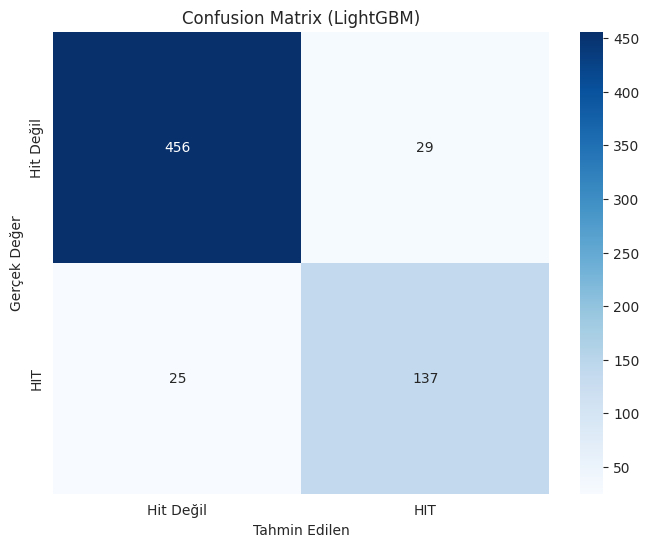

In [ ]:
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Hit Değil', 'HIT'],
            yticklabels=['Hit Değil', 'HIT'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Confusion Matrix (LightGBM)')
plt.show()

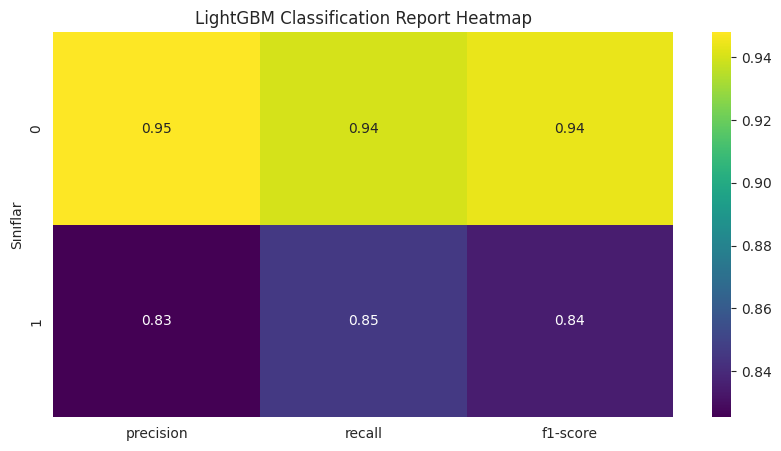

In [ ]:
report_lgbm = classification_report(y_test, y_pred_lgbm, output_dict=True)

report_df_lgbm = pd.DataFrame(report_lgbm).transpose()

summary_rows_lgbm = report_df_lgbm.loc[['accuracy', 'macro avg', 'weighted avg']]
report_df_lgbm = report_df_lgbm.drop(labels=['accuracy', 'macro avg', 'weighted avg'])

plt.figure(figsize=(10, 5))
sns.heatmap(report_df_lgbm[['precision', 'recall', 'f1-score']], annot=True, cmap='viridis', fmt='.2f')
plt.title('LightGBM Classification Report Heatmap')
plt.ylabel('Sınıflar')
plt.show()

## MLPClassifier




In [ ]:
# 1. Sinir ağları için verileri mutlaka ölçeklendirmeliyiz (0-1 veya standartlaştırma)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Modeli Oluşturma
# hidden_layer_sizes=(64, 32): 64 nöronluk ilk katman ve 32 nöronluk ikinci katman
mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32),
                          activation='relu',
                          solver='adam',
                          max_iter=500,
                          random_state=42)

# 3. Eğitme
mlp_model.fit(X_train_scaled, y_train)

# 4. Tahmin ve Rapor
y_pred_mlp = mlp_model.predict(X_test_scaled)
print("--- Yapay Sinir Ağları (MLP) Raporu ---")
print(confusion_matrix(y_test,y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))
print(print(accuracy_score(y_test, y_pred_mlp)))

--- Yapay Sinir Ağları (MLP) Raporu ---
[[460  25]
 [ 29 133]]
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       485
           1       0.84      0.82      0.83       162

    accuracy                           0.92       647
   macro avg       0.89      0.88      0.89       647
weighted avg       0.92      0.92      0.92       647

0.9165378670788253
None


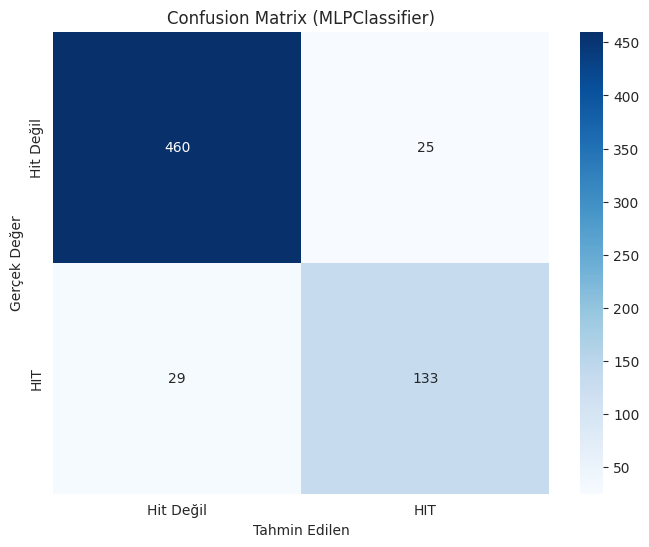

In [ ]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Hit Değil', 'HIT'],
            yticklabels=['Hit Değil', 'HIT'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Confusion Matrix (MLPClassifier)')
plt.show()

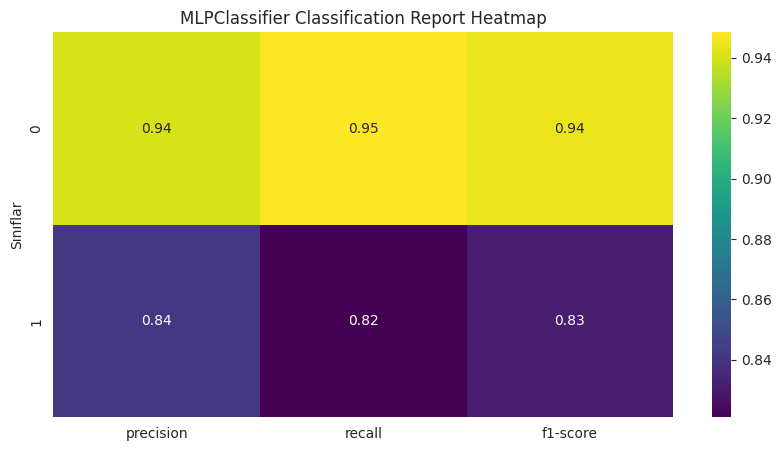

In [ ]:
report_mlp = classification_report(y_test, y_pred_mlp, output_dict=True)

report_df_mlp = pd.DataFrame(report_mlp).transpose()

summary_rows_mlp = report_df_mlp.loc[['accuracy', 'macro avg', 'weighted avg']]
report_df_mlp = report_df_mlp.drop(labels=['accuracy', 'macro avg', 'weighted avg'])

plt.figure(figsize=(10, 5))
sns.heatmap(report_df_mlp[['precision', 'recall', 'f1-score']], annot=True, cmap='viridis', fmt='.2f')
plt.title('MLPClassifier Classification Report Heatmap')
plt.ylabel('Sınıflar')
plt.show()

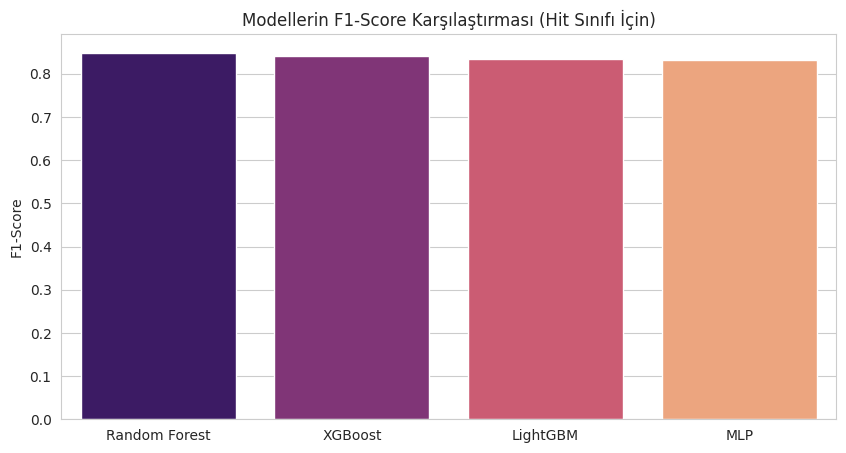

In [ ]:
from sklearn.metrics import f1_score

models = {
    "Random Forest": f1_score(y_test, y_pred),
    "XGBoost": f1_score(y_test, y_pred_xgb),
    "LightGBM": f1_score(y_test, y_pred_lgbm),
    "MLP": f1_score(y_test, y_pred_mlp)

}

# Sonuçları görselleştir
plt.figure(figsize=(10, 5))
sns.barplot(x=list(models.keys()), y=list(models.values()), palette='magma')
plt.title('Modellerin F1-Score Karşılaştırması (Hit Sınıfı İçin)')
plt.ylabel('F1-Score')
plt.show()

F1-score'a göre, Random Forest Classifier bu modeller arasında en iyi performansı göstermiştir (F1-score: 0.849). 'Hit' sınıfını doğru tahmin etme yeteneği açısından en dengeli performansı sunduğu için, bu problemde Random Forest'ı tercih etmek mantıklı olacaktır. F1-score, özellikle sınıf dengesizliği olan durumlarda (burada 'hit' filmler 'hit olmayan' filmlere göre daha az olabilir) hem kesinlik (precision) hem de duyarlılık (recall) arasındaki dengeyi iyi yansıttığı için önemli bir metriktir.